# Analysis (AUROC / Precision–Recall)

This notebook loads `initial_results_15507.csv` (produced by `src/run_model_on_dataset.py`) and generates:
- AUROC curves per `(dataset, categorie, subcategorie)`
- Precision–Recall curves per `(dataset, categorie, subcategorie)`
- 4-panel averaged curves (all vs. single-answer subset)

In [1]:
from __future__ import annotations

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

plt.rcParams["figure.dpi"] = 120
RESULTS_FILE_NAME = 'before_finetuning_results_full.csv'

In [2]:
def find_repo_root(start: Path | None = None) -> Path:
    """Find repo root by walking parents until src/run_model_on_dataset.py exists."""
    start = (start or Path.cwd()).resolve()
    for p in [start, *start.parents]:
        if (p / "src" / "run_model_on_dataset.py").exists():
            return p
    raise FileNotFoundError("Could not find repo root containing src/run_model_on_dataset.py")


def find_results_csv(repo_root: Path, file_name: str) -> Path:
    """Locate results file in common locations and return absolute path."""
    candidates = [
        repo_root / RESULTS_FILE_NAME,
        repo_root / "hpc" / RESULTS_FILE_NAME,
        repo_root / "analysis" / RESULTS_FILE_NAME,
    ]
    for c in candidates:
        if c.exists():
            return c.resolve()
    raise FileNotFoundError(
        f"Could not find {RESULTS_FILE_NAME}. Tried: " + ", ".join(str(c) for c in candidates)
    )


REPO_ROOT = find_repo_root()
RESULTS_PATH = find_results_csv(REPO_ROOT, RESULTS_FILE_NAME)
print("Repo root:", REPO_ROOT)
print("Results:", RESULTS_PATH)

Repo root: /home/oskar/school/transformers/tf_project
Results: /home/oskar/school/transformers/tf_project/hpc/before_finetuning_results_full.csv


In [3]:
df = pd.read_csv(RESULTS_PATH, sep=";", low_memory=False)
print("Rows:", len(df))
display(df.head(3))

# Normalize group keys (empty -> NA)
for col in ["dataset", "categorie", "subcategorie"]:
    if col not in df.columns:
        raise KeyError(f"Missing required column: {col}")
    df[col] = df[col].astype("string")
    df[col] = df[col].fillna("NA")
    df[col] = df[col].replace("", "NA")

# Ensure correctness columns are numeric 0/1
for c in ["first_try_correct", "second_try_correct"]:
    if c in df.columns:
        df[c] = df[c].astype("float").fillna(0).astype(int)

Rows: 25455


,index,dataset,categorie,subcategorie,question,question_type,right_answer,first_try_answer,first_try_correct,first_try_max_prob,first_try_entropy,first_try_margin,first_try_verbal,second_try_answer,second_try_correct,second_try_max_prob,second_try_entropy,second_try_margin,second_try_verbal
0,0,strategyqa_dev,NaN,NaN,Will the Albany in Georgia reach a hundred tho...,true/false,['False'],['false'],True,99.83,99.37,1.00,85.0,NaN,NaN,NaN,NaN,NaN,NaN
1,1,strategyqa_dev,NaN,NaN,Is the language used in Saint Vincent and the ...,true/false,['True'],['true'],True,100.00,100.00,1.00,95.0,NaN,NaN,NaN,NaN,NaN,NaN
2,2,strategyqa_dev,NaN,NaN,Is greed the most prevalent of the Seven Deadl...,true/false,['False'],['false'],True,93.28,90.95,0.87,85.0,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
METRICS = ["max_prob", "entropy", "margin", "verbal"]
METRIC_COLORS = {
    "max_prob": "tab:blue",
    "entropy": "tab:orange",
    "margin": "tab:green",
    "verbal": "tab:red",
}


def _score_col(try_name: str, metric: str) -> str:
    return f"{try_name}_try_{metric}"


def _label_col(try_name: str) -> str:
    return f"{try_name}_try_correct"


def _coerce_numeric(series: pd.Series) -> np.ndarray:
    return pd.to_numeric(series, errors="coerce").astype(float).to_numpy()


def _invert_scores(scores: np.ndarray) -> np.ndarray:
    scores = scores.astype(float)
    finite = np.isfinite(scores)
    if not finite.any():
        return scores
    max_val = float(np.nanmax(scores[finite]))
    # Heuristic: margin is typically <=1, other confidences are 0..100
    scale = 1.0 if max_val <= 1.0 else 100.0
    return scale - scores


def compute_roc(y_true: np.ndarray, scores: np.ndarray) -> tuple[np.ndarray, np.ndarray, float] | None:
    mask = np.isfinite(scores)
    y = y_true[mask]
    s = scores[mask]
    if y.size == 0 or np.unique(y).size < 2:
        return None
    fpr, tpr, _ = roc_curve(y, s)
    return fpr, tpr, float(auc(fpr, tpr))


def compute_pr(y_true: np.ndarray, scores: np.ndarray) -> tuple[np.ndarray, np.ndarray, float] | None:
    mask = np.isfinite(scores)
    y = y_true[mask]
    s = scores[mask]
    if y.size == 0 or y.sum() == 0:
        return None
    precision, recall, _ = precision_recall_curve(y, s)
    ap = float(average_precision_score(y, s))
    return recall, precision, ap


def iter_groups(frame: pd.DataFrame):
    keys = ("dataset", "categorie", "subcategorie")
    for (dataset, categorie, subcategorie), g in frame.groupby(list(keys), dropna=False):
        yield (str(dataset), str(categorie), str(subcategorie)), g.copy()

## 1) AUROC curves per (dataset, categorie, subcategorie)
Each subplot: random classifier + 4 metrics (solid = first try, dotted = second try).
If a curve has AUROC < 0.5, it is inverted and marked in the legend.

Number of subplots: 11


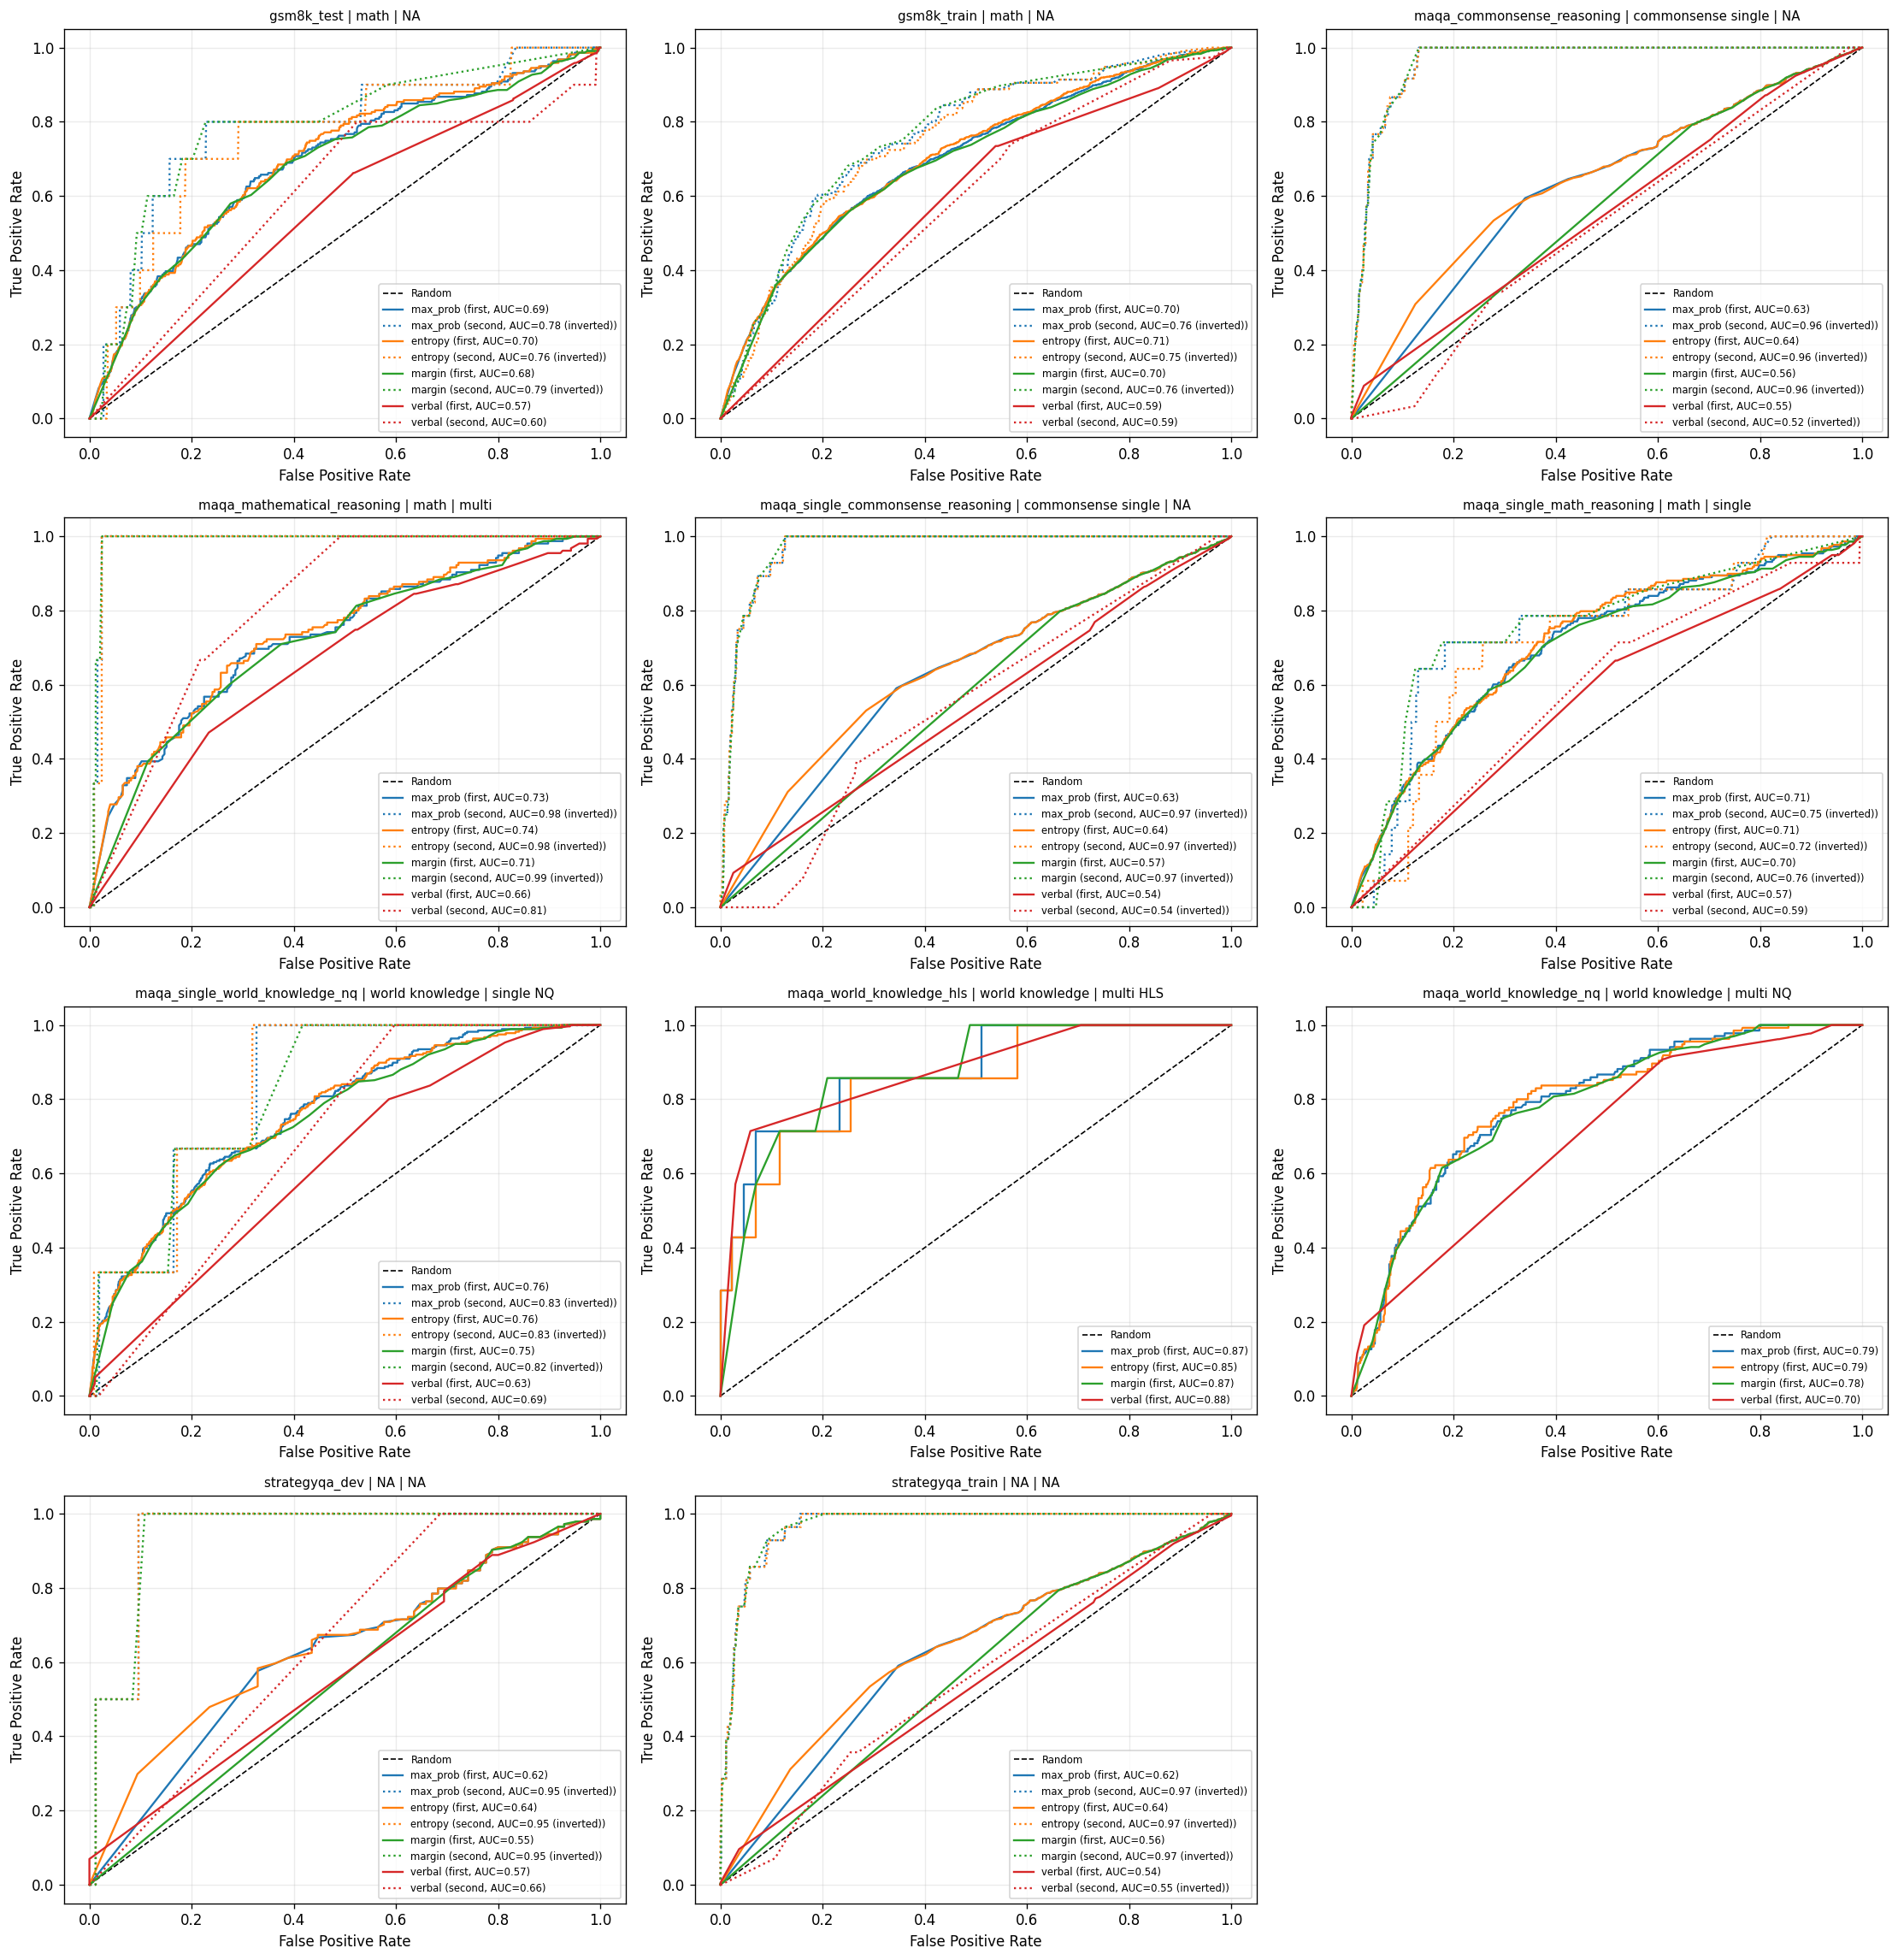

In [5]:
groups = list(iter_groups(df))
print("Number of subplots:", len(groups))

n = len(groups)
if n == 0:
    raise ValueError("No groups found to plot")

ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6.2 * ncols, 4.8 * nrows), squeeze=False)
axes_flat = axes.flatten()

for ax in axes_flat[n:]:
    ax.axis("off")

for i, ((dataset, categorie, subcategorie), g) in enumerate(groups):
    ax = axes_flat[i]
    title = f"{dataset} | {categorie} | {subcategorie}"
    ax.set_title(title, fontsize=9)
    ax.plot([0, 1], [0, 1], "k--", lw=1.0, label="Random")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.grid(True, alpha=0.25)

    for metric in METRICS:
        color = METRIC_COLORS.get(metric, None)
        for try_name, linestyle in [("first", "-"), ("second", ":")]:
            lbl_col = _label_col(try_name)
            sc_col = _score_col(try_name, metric)
            if lbl_col not in g.columns or sc_col not in g.columns:
                continue
            y_true = g[lbl_col].to_numpy(dtype=int)
            scores = _coerce_numeric(g[sc_col])
            roc_res = compute_roc(y_true, scores)
            if roc_res is None:
                continue
            fpr, tpr, roc_auc = roc_res
            inverted = False
            if roc_auc < 0.5:
                inv_scores = _invert_scores(scores)
                roc_res2 = compute_roc(y_true, inv_scores)
                if roc_res2 is not None:
                    fpr, tpr, roc_auc = roc_res2
                    inverted = True
            suffix = " (inverted)" if inverted else ""
            label = f"{metric} ({try_name}, AUC={roc_auc:.2f}{suffix})"
            ax.plot(fpr, tpr, linestyle=linestyle, color=color, lw=1.4, label=label)

    ax.legend(fontsize=7, loc="lower right")

plt.tight_layout()
plt.show()

## 2) Precision–Recall curves per (dataset, categorie, subcategorie)
Each subplot: random classifier baseline + 4 metrics (solid = first try, dotted = second try).

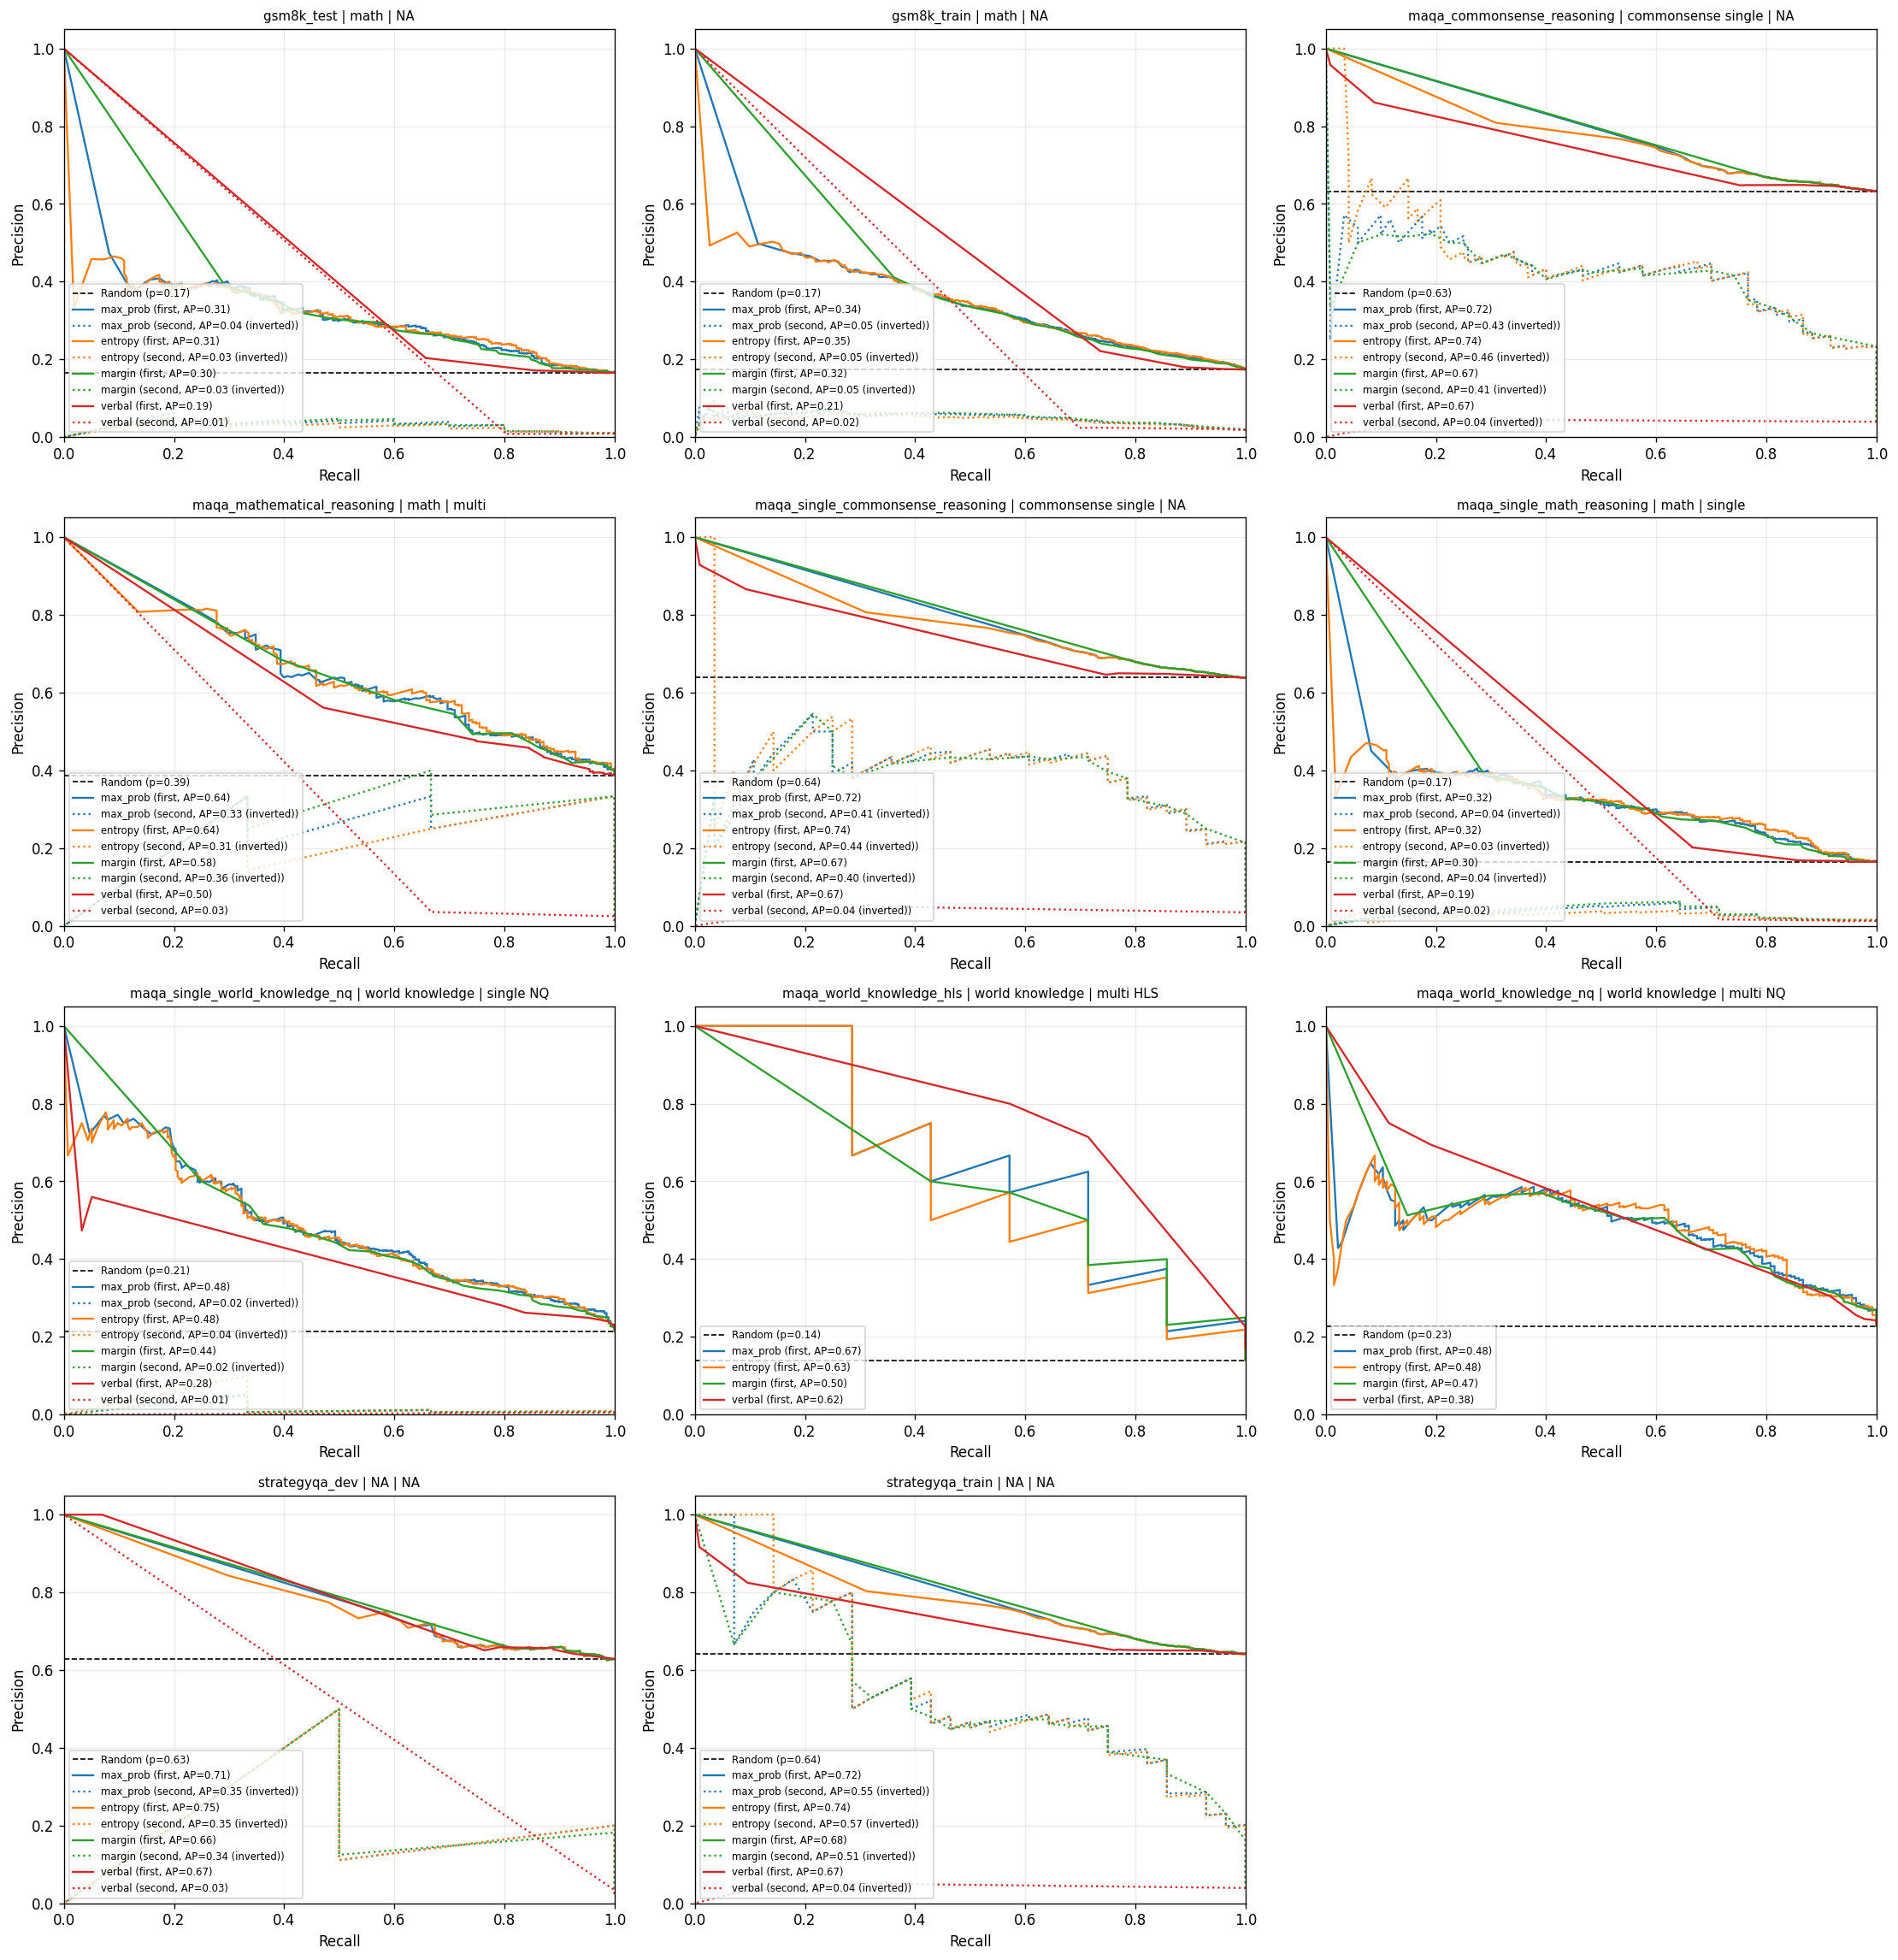

In [6]:
groups = list(iter_groups(df))
n = len(groups)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6.2 * ncols, 4.8 * nrows), squeeze=False)
axes_flat = axes.flatten()

for ax in axes_flat[n:]:
    ax.axis("off")

for i, ((dataset, categorie, subcategorie), g) in enumerate(groups):
    ax = axes_flat[i]
    title = f"{dataset} | {categorie} | {subcategorie}"
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.grid(True, alpha=0.25)

    # Random classifier PR baseline (single line to keep total = 9).
    base_rate = float(g.get("first_try_correct", pd.Series([0])).mean())
    ax.plot([0, 1], [base_rate, base_rate], "k--", lw=1.0, label=f"Random (p={base_rate:.2f})")

    for metric in METRICS:
        color = METRIC_COLORS.get(metric, None)
        for try_name, linestyle in [("first", "-"), ("second", ":")]:
            lbl_col = _label_col(try_name)
            sc_col = _score_col(try_name, metric)
            if lbl_col not in g.columns or sc_col not in g.columns:
                continue
            y_true = g[lbl_col].to_numpy(dtype=int)
            scores = _coerce_numeric(g[sc_col])

            # Apply the SAME inversion decision as ROC: invert when AUROC < 0.5.
            roc_res = compute_roc(y_true, scores)
            inverted = False
            pr_scores = scores
            if roc_res is not None:
                _fpr, _tpr, roc_auc = roc_res
                if roc_auc < 0.5:
                    pr_scores = _invert_scores(scores)
                    inverted = True

            pr_res = compute_pr(y_true, pr_scores)
            if pr_res is None:
                continue
            recall, precision, ap = pr_res
            suffix = " (inverted)" if inverted else ""
            label = f"{metric} ({try_name}, AP={ap:.2f}{suffix})"
            ax.plot(recall, precision, linestyle=linestyle, color=color, lw=1.4, label=label)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=7, loc="lower left")

plt.tight_layout()
plt.show()

## 2.1 Last step's modified graphs
Last step's modified graphs where the legend is outside of the subplot, specificaly under it, with some space between the graph and the legend. Also the lines and the text in the legend is in columns of three.

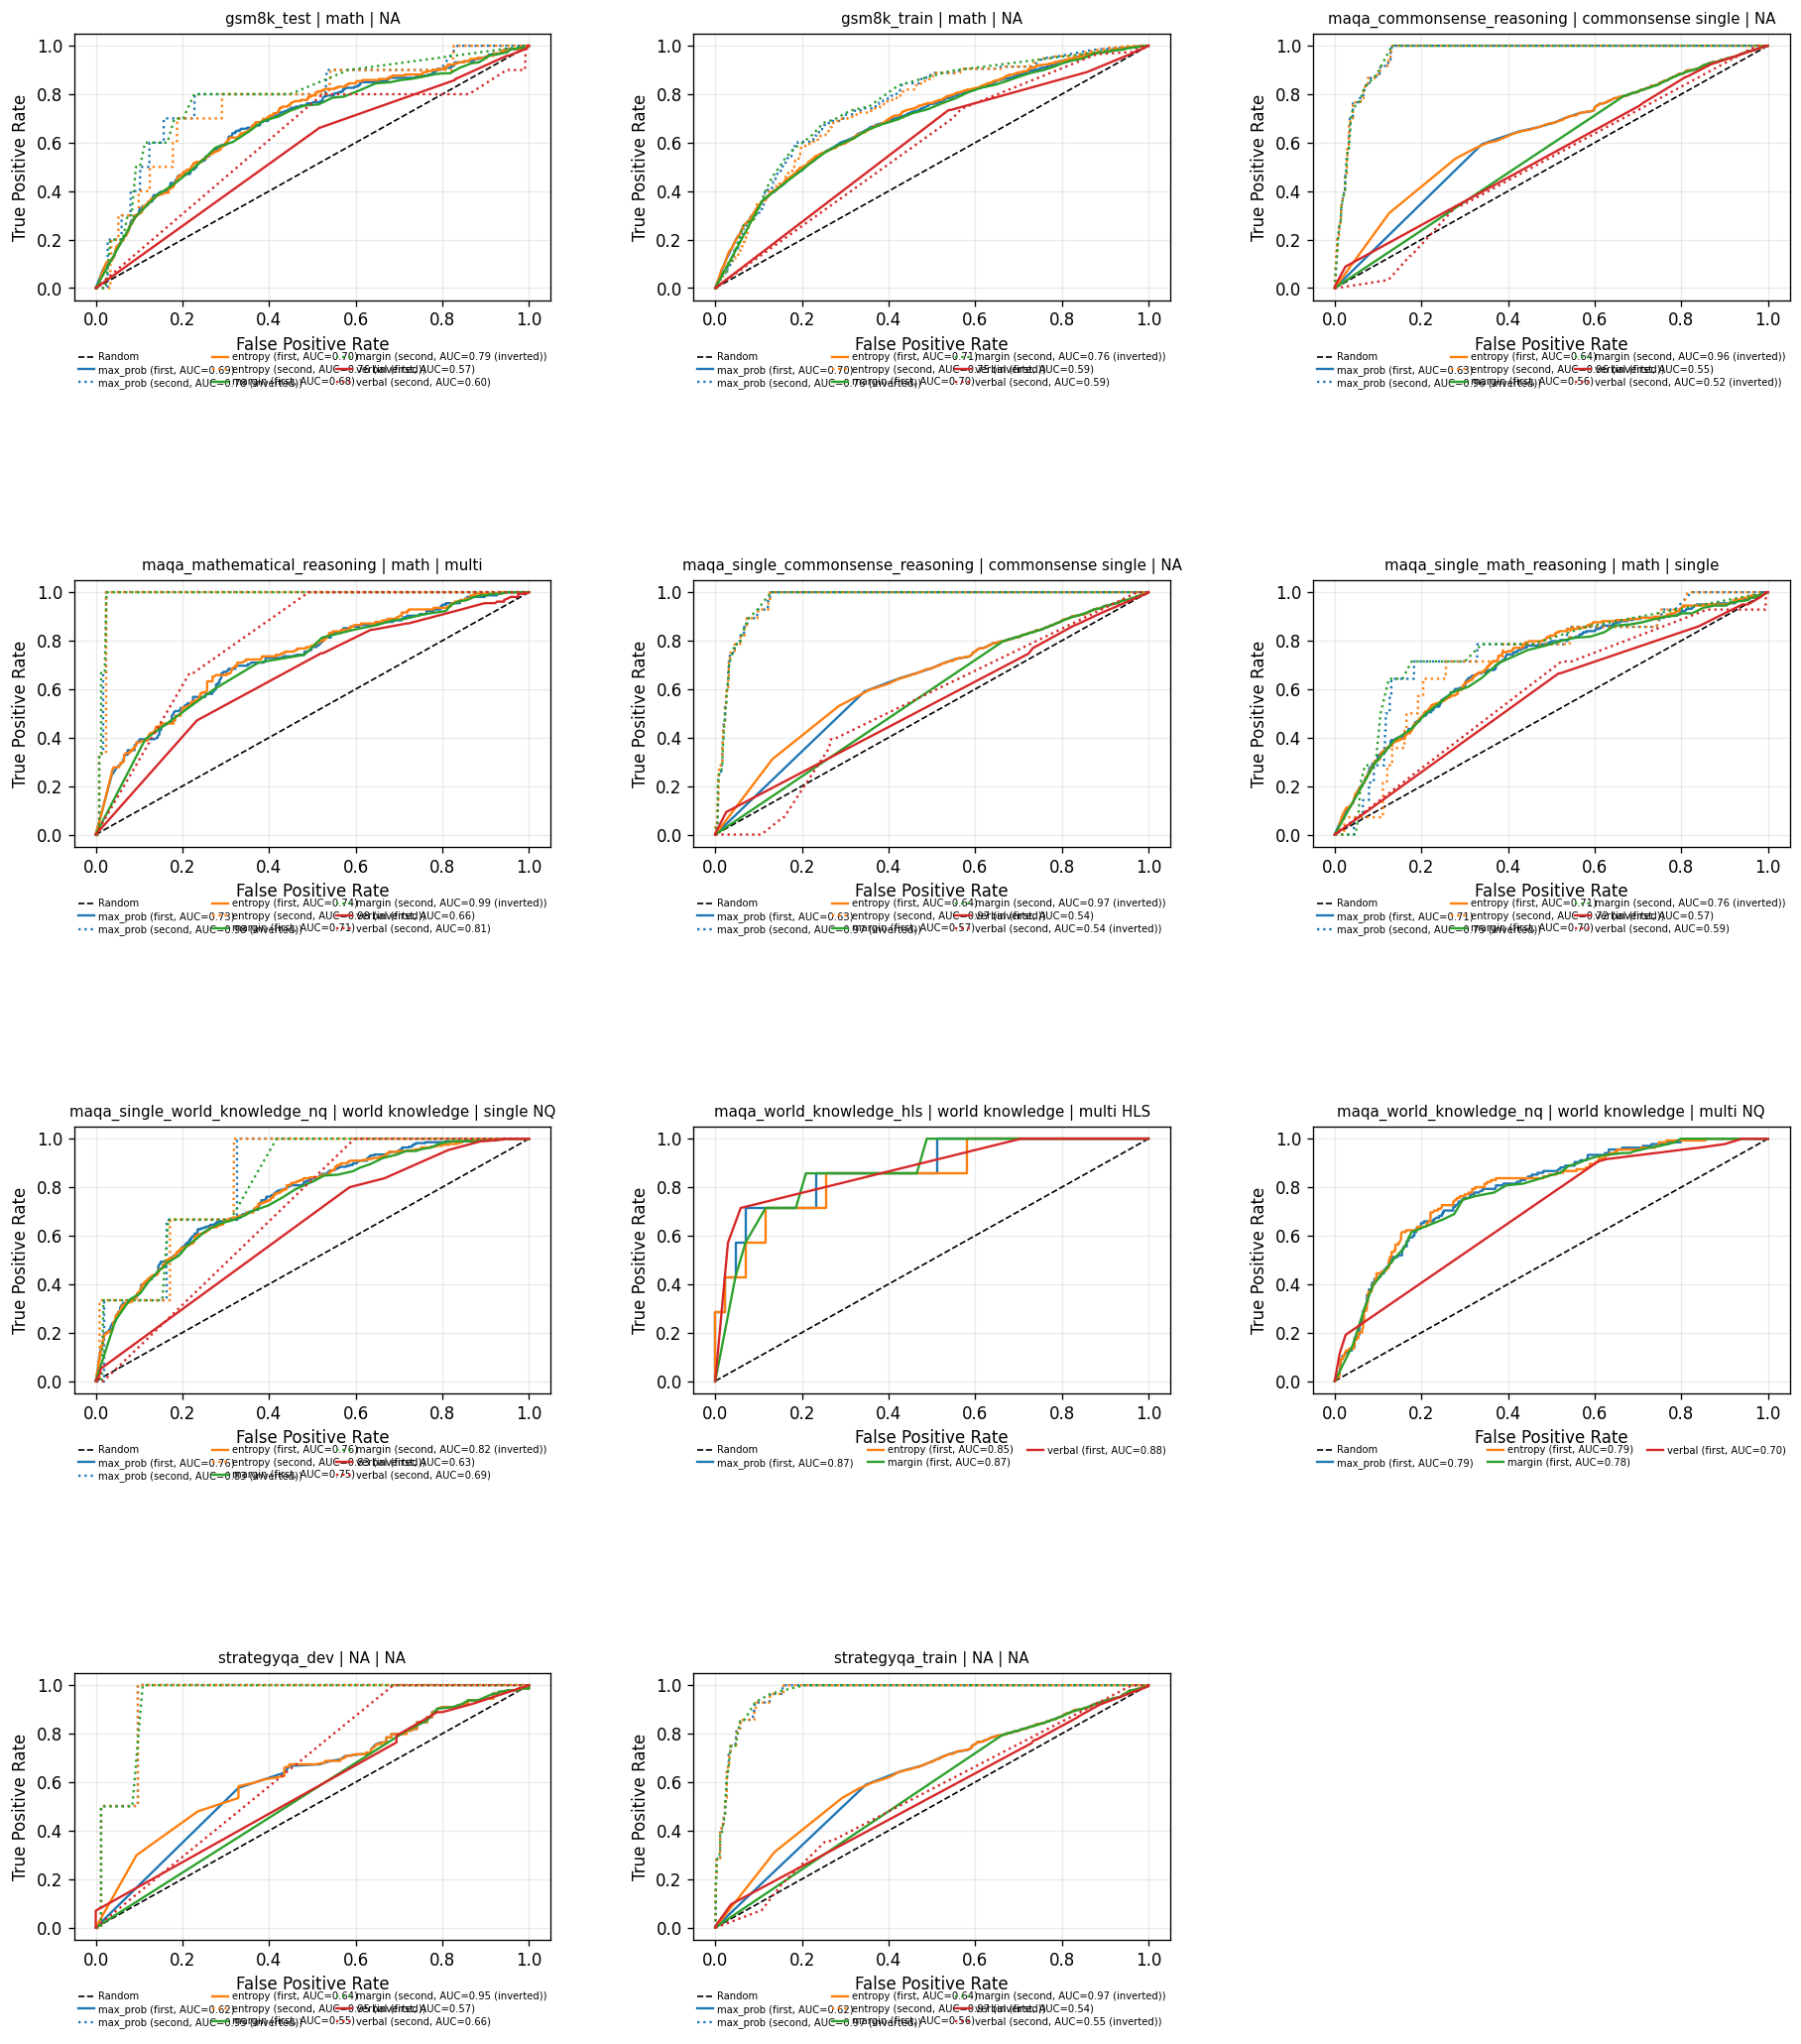

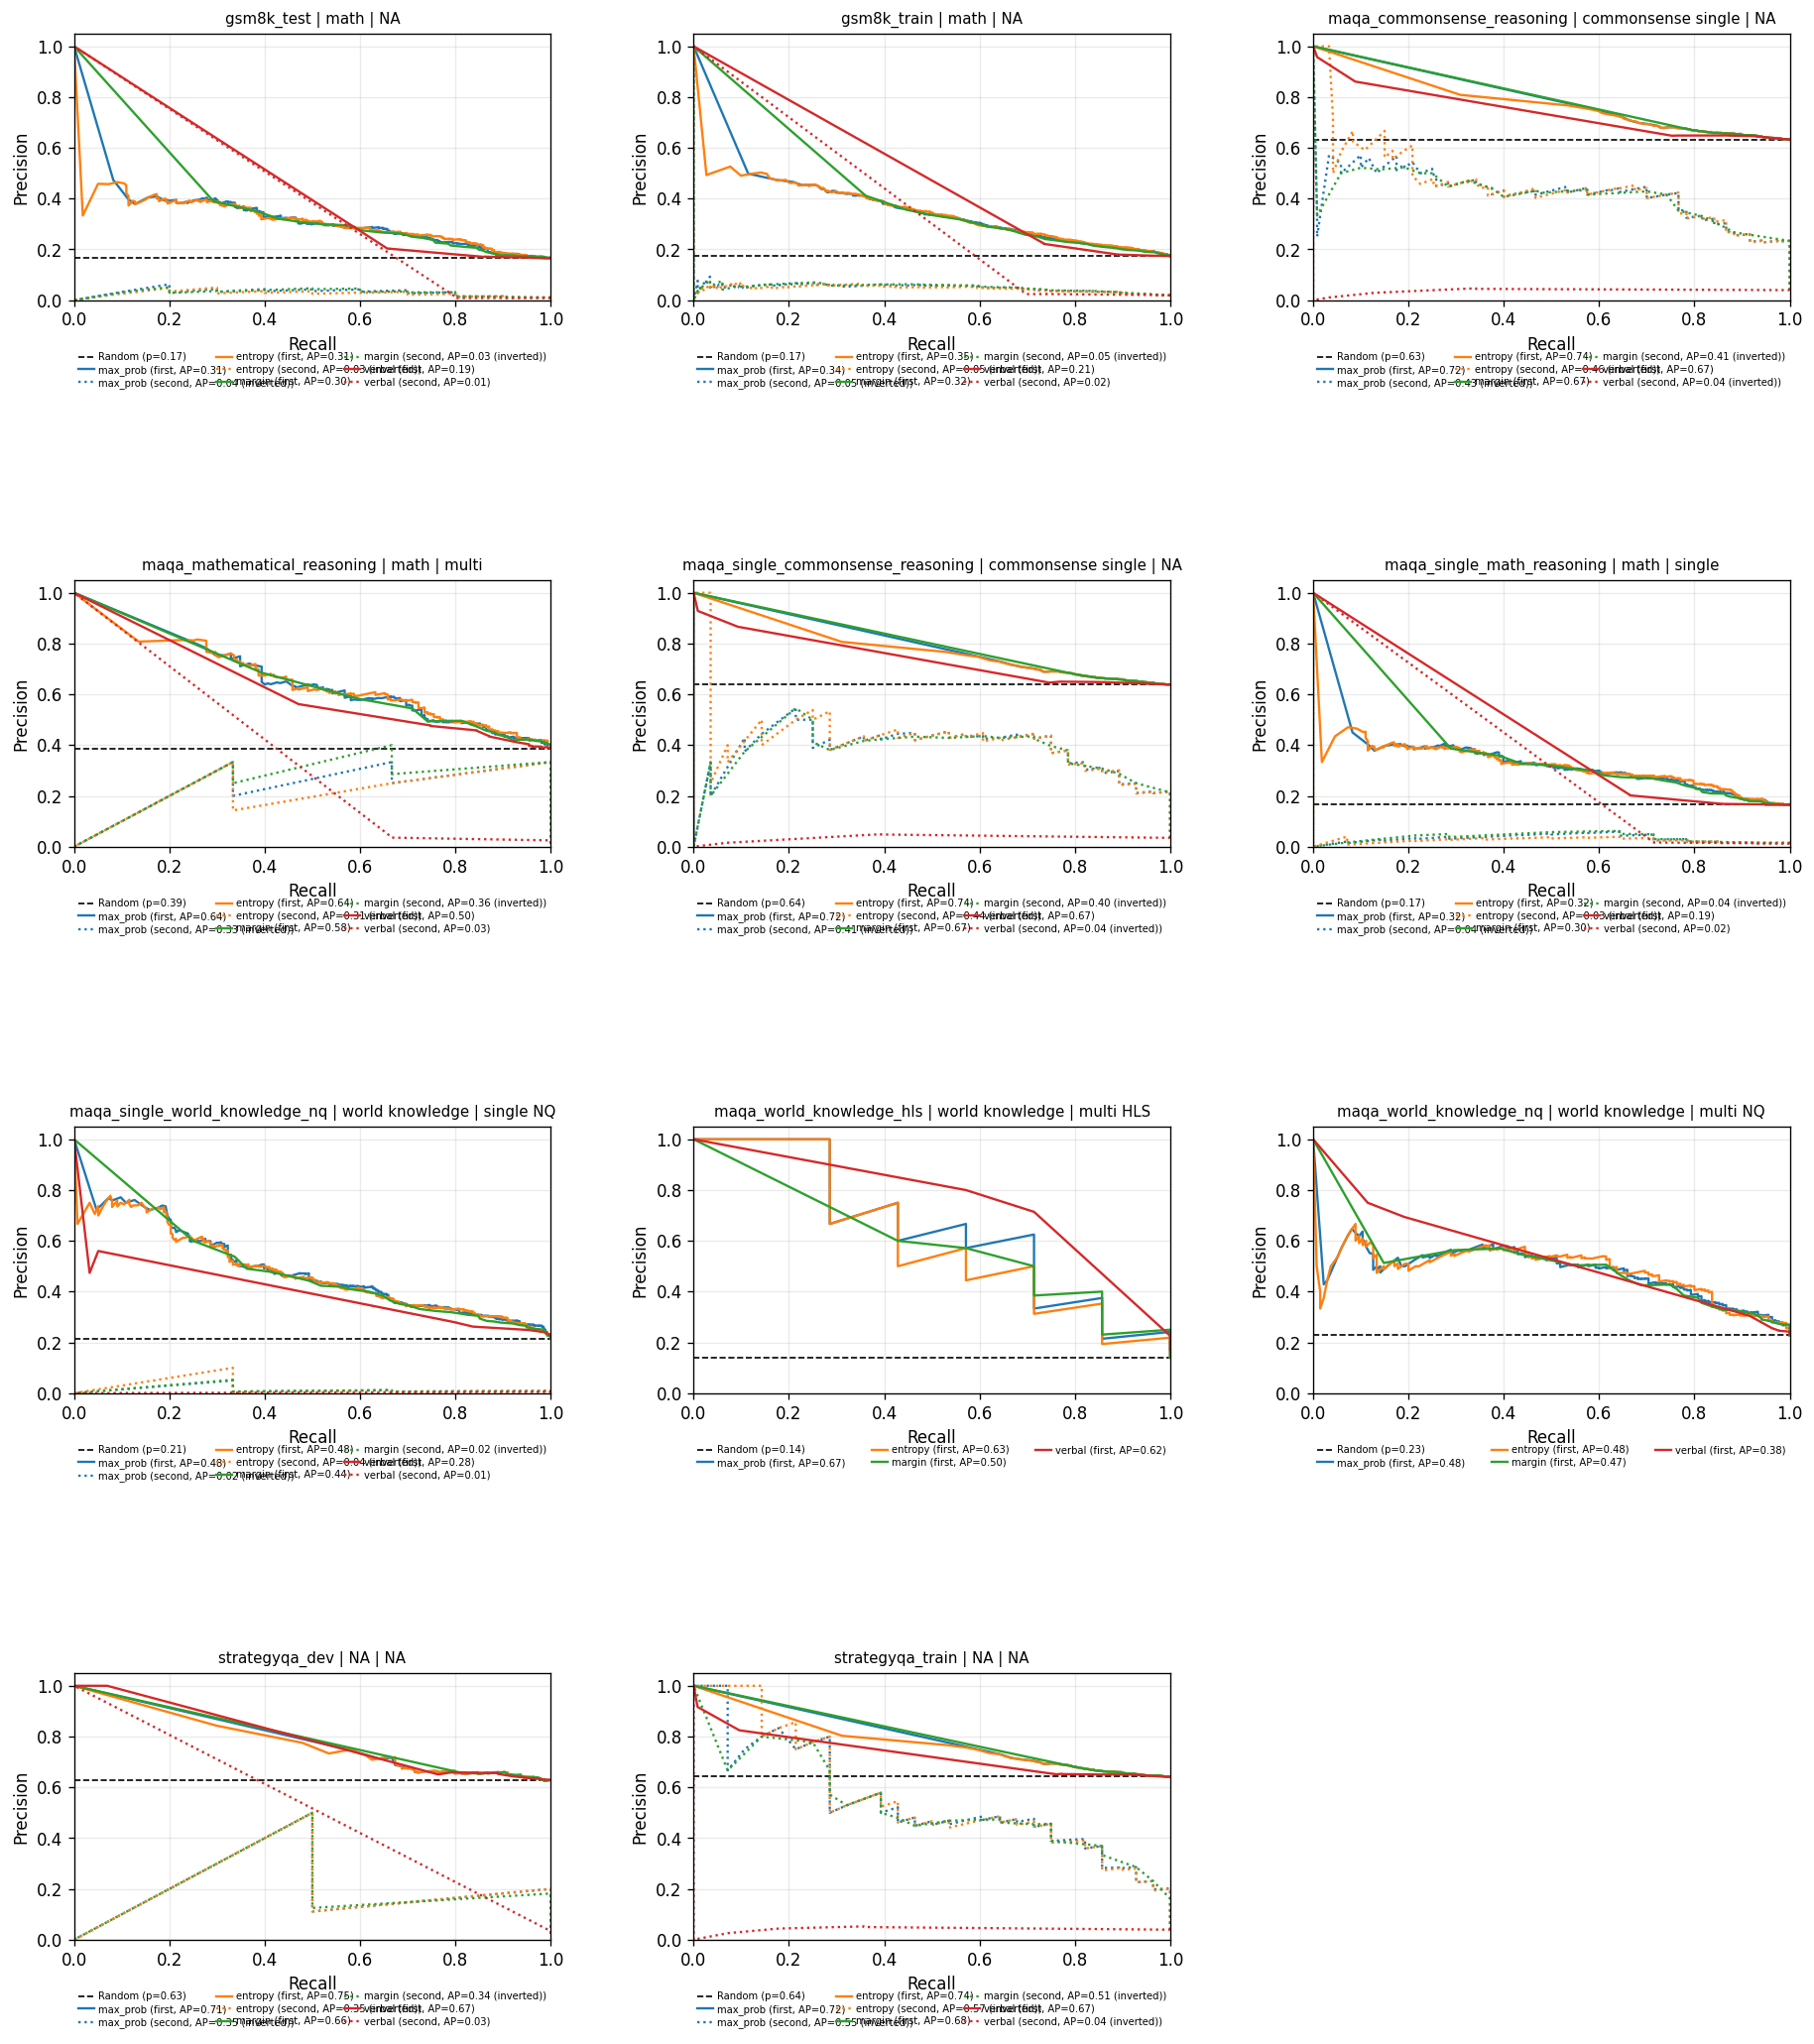

In [7]:
# 2.1) Last step's modified graphs: per-group ROC + PR,
# with the legend outside each subplot (below), spaced from the plot, in 3 columns.

LEGEND_NCOLS = 3
LEGEND_Y = -0.32  # negative => below axes; tuned to keep legends close but outside
LEGEND_FONTSIZE = 6
LEGEND_HEIGHT = 0.14
LEGEND_ROW_SPACING = 0.25
FIG_W_PER_COL = 6.2
FIG_H_PER_ROW = 5.2
HSPACE = 1.05
WSPACE = 0.30

def _legend_below_axis(ax, *, ncol: int = LEGEND_NCOLS, y: float = LEGEND_Y, fontsize: int = LEGEND_FONTSIZE) -> None:
    handles, labels = ax.get_legend_handles_labels()
    # Constrain legend to the axes width so it won't overlap neighboring subplots.
    ax.legend(
        handles,
        labels,
        loc="upper left",
        bbox_to_anchor=(0.0, y, 1.0, LEGEND_HEIGHT),
        bbox_transform=ax.transAxes,
        mode="expand",
        ncol=ncol,
        fontsize=fontsize,
        frameon=False,
        borderaxespad=0.0,
        columnspacing=1.0,
        handletextpad=0.4,
        labelspacing=LEGEND_ROW_SPACING,
        handlelength=1.6,
    )
    

def plot_group_roc_with_legends_below(frame: pd.DataFrame) -> None:
    groups = list(iter_groups(frame))
    n = len(groups)
    if n == 0:
        raise ValueError("No groups found to plot")

    ncols = 3
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(FIG_W_PER_COL * ncols, FIG_H_PER_ROW * nrows),
        squeeze=False,
    )
    axes_flat = axes.flatten()
    for ax in axes_flat[n:]:
        ax.axis("off")

    for i, ((dataset, categorie, subcategorie), g) in enumerate(groups):
        ax = axes_flat[i]
        ax.set_title(f"{dataset} | {categorie} | {subcategorie}", fontsize=9)
        ax.plot([0, 1], [0, 1], "k--", lw=1.0, label="Random")
        ax.set_xlabel("False Positive Rate")
        ax.set_ylabel("True Positive Rate")
        ax.grid(True, alpha=0.25)

        for metric in METRICS:
            color = METRIC_COLORS.get(metric, None)
            for try_name, linestyle in [("first", "-"), ("second", ":")]:
                lbl_col = _label_col(try_name)
                sc_col = _score_col(try_name, metric)
                if lbl_col not in g.columns or sc_col not in g.columns:
                    continue
                y_true = g[lbl_col].to_numpy(dtype=int)
                scores = _coerce_numeric(g[sc_col])
                roc_res = compute_roc(y_true, scores)
                if roc_res is None:
                    continue
                fpr, tpr, roc_auc = roc_res
                inverted = False
                if roc_auc < 0.5:
                    inv_scores = _invert_scores(scores)
                    roc_res2 = compute_roc(y_true, inv_scores)
                    if roc_res2 is not None:
                        fpr, tpr, roc_auc = roc_res2
                        inverted = True
                suffix = " (inverted)" if inverted else ""
                ax.plot(
                    fpr,
                    tpr,
                    linestyle=linestyle,
                    color=color,
                    lw=1.4,
                    label=f"{metric} ({try_name}, AUC={roc_auc:.2f}{suffix})",
                )

        _legend_below_axis(ax)

    fig.subplots_adjust(hspace=HSPACE, wspace=WSPACE)
    plt.show()
    

def plot_group_pr_with_legends_below(frame: pd.DataFrame) -> None:
    groups = list(iter_groups(frame))
    n = len(groups)
    if n == 0:
        raise ValueError("No groups found to plot")

    ncols = 3
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(FIG_W_PER_COL * ncols, FIG_H_PER_ROW * nrows),
        squeeze=False,
    )
    axes_flat = axes.flatten()
    for ax in axes_flat[n:]:
        ax.axis("off")

    for i, ((dataset, categorie, subcategorie), g) in enumerate(groups):
        ax = axes_flat[i]
        ax.set_title(f"{dataset} | {categorie} | {subcategorie}", fontsize=9)
        ax.set_xlabel("Recall")
        ax.set_ylabel("Precision")
        ax.grid(True, alpha=0.25)

        base_rate = float(g.get("first_try_correct", pd.Series([0])).mean())
        ax.plot([0, 1], [base_rate, base_rate], "k--", lw=1.0, label=f"Random (p={base_rate:.2f})")

        for metric in METRICS:
            color = METRIC_COLORS.get(metric, None)
            for try_name, linestyle in [("first", "-"), ("second", ":")]:
                lbl_col = _label_col(try_name)
                sc_col = _score_col(try_name, metric)
                if lbl_col not in g.columns or sc_col not in g.columns:
                    continue
                y_true = g[lbl_col].to_numpy(dtype=int)
                scores = _coerce_numeric(g[sc_col])

                # Apply the same inversion decision as ROC: invert when AUROC < 0.5.
                roc_res = compute_roc(y_true, scores)
                inverted = False
                pr_scores = scores
                if roc_res is not None:
                    _fpr, _tpr, roc_auc = roc_res
                    if roc_auc < 0.5:
                        pr_scores = _invert_scores(scores)
                        inverted = True

                pr_res = compute_pr(y_true, pr_scores)
                if pr_res is None:
                    continue
                recall, precision, ap = pr_res
                suffix = " (inverted)" if inverted else ""
                ax.plot(
                    recall,
                    precision,
                    linestyle=linestyle,
                    color=color,
                    lw=1.4,
                    label=f"{metric} ({try_name}, AP={ap:.2f}{suffix})",
                )

        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1.05)
        _legend_below_axis(ax)

    fig.subplots_adjust(hspace=HSPACE, wspace=WSPACE)
    plt.show()
    

plot_group_roc_with_legends_below(df)
plot_group_pr_with_legends_below(df)

## 3) Averaged curves (4 panels)
Panels:
1. Average ROC across all groups
2. Average PR across all groups
3. Average ROC excluding MAQA multi-answer datasets (`'maqa'` and not `'single'`)
4. Average PR excluding MAQA multi-answer datasets (`'maqa'` and not `'single'`)

In [8]:
def average_roc_curves(frame: pd.DataFrame) -> dict[tuple[str, str, str], tuple[np.ndarray, np.ndarray, float]]:
    """Return averaged ROC curves keyed by (try_name, metric, variant).
    
    Variants:
    - ("first", metric, "plain")   : no inversion
    - ("second", metric, "inv")    : ALWAYS inverted scores
    - ("second", metric, "plain")  : no inversion
    """
    fpr_grid = np.linspace(0.0, 1.0, 201)
    acc: dict[tuple[str, str, str], list[np.ndarray]] = {}
    for (_key, g) in iter_groups(frame):
        for metric in METRICS:
            # First try (plain)
            lbl_col = _label_col("first")
            sc_col = _score_col("first", metric)
            if lbl_col in g.columns and sc_col in g.columns:
                y_true = g[lbl_col].to_numpy(dtype=int)
                scores = _coerce_numeric(g[sc_col])
                roc_res = compute_roc(y_true, scores)
                if roc_res is not None:
                    fpr, tpr, _roc_auc = roc_res
                    if fpr[0] > 0:
                        fpr = np.concatenate([[0.0], fpr])
                        tpr = np.concatenate([[0.0], tpr])
                    if fpr[-1] < 1:
                        fpr = np.concatenate([fpr, [1.0]])
                        tpr = np.concatenate([tpr, [1.0]])
                    tpr_i = np.interp(fpr_grid, fpr, tpr)
                    acc.setdefault(("first", metric, "plain"), []).append(tpr_i)
            # Second try (plain + always-inverted)
            lbl_col = _label_col("second")
            sc_col = _score_col("second", metric)
            if lbl_col in g.columns and sc_col in g.columns:
                y_true = g[lbl_col].to_numpy(dtype=int)
                scores = _coerce_numeric(g[sc_col])
                # Second try (plain)
                roc_res = compute_roc(y_true, scores)
                if roc_res is not None:
                    fpr, tpr, _roc_auc = roc_res
                    if fpr[0] > 0:
                        fpr = np.concatenate([[0.0], fpr])
                        tpr = np.concatenate([[0.0], tpr])
                    if fpr[-1] < 1:
                        fpr = np.concatenate([fpr, [1.0]])
                        tpr = np.concatenate([tpr, [1.0]])
                    tpr_i = np.interp(fpr_grid, fpr, tpr)
                    acc.setdefault(("second", metric, "plain"), []).append(tpr_i)
                # Second try (always inverted)
                roc_res_inv = compute_roc(y_true, _invert_scores(scores))
                if roc_res_inv is not None:
                    fpr, tpr, _roc_auc = roc_res_inv
                    if fpr[0] > 0:
                        fpr = np.concatenate([[0.0], fpr])
                        tpr = np.concatenate([[0.0], tpr])
                    if fpr[-1] < 1:
                        fpr = np.concatenate([fpr, [1.0]])
                        tpr = np.concatenate([tpr, [1.0]])
                    tpr_i = np.interp(fpr_grid, fpr, tpr)
                    acc.setdefault(("second", metric, "inv"), []).append(tpr_i)
    out: dict[tuple[str, str, str], tuple[np.ndarray, np.ndarray, float]] = {}
    for k, tprs in acc.items():
        mean_tpr = np.mean(np.vstack(tprs), axis=0)
        out[k] = (fpr_grid, mean_tpr, float(auc(fpr_grid, mean_tpr)))
    return out


def average_pr_curves(frame: pd.DataFrame) -> dict[tuple[str, str, str], tuple[np.ndarray, np.ndarray, float]]:
    """Return averaged PR curves keyed by (try_name, metric, variant).
    
    Variants:
    - ("first", metric, "plain")   : no inversion
    - ("second", metric, "inv")    : ALWAYS inverted scores
    - ("second", metric, "plain")  : no inversion
    Returns (recall_grid, mean_precision, mean_ap).
    """
    recall_grid = np.linspace(0.0, 1.0, 201)
    acc: dict[tuple[str, str, str], list[np.ndarray]] = {}
    aps: dict[tuple[str, str, str], list[float]] = {}
    for (_key, g) in iter_groups(frame):
        for metric in METRICS:
            # First try (plain)
            lbl_col = _label_col("first")
            sc_col = _score_col("first", metric)
            if lbl_col in g.columns and sc_col in g.columns:
                y_true = g[lbl_col].to_numpy(dtype=int)
                scores = _coerce_numeric(g[sc_col])
                pr_res = compute_pr(y_true, scores)
                if pr_res is not None:
                    recall, precision, ap = pr_res
                    # make recall ascending for interpolation
                    recall = recall[::-1]
                    precision = precision[::-1]
                    if recall[0] > 0:
                        recall = np.concatenate([[0.0], recall])
                        precision = np.concatenate([[precision[0]], precision])
                    if recall[-1] < 1:
                        recall = np.concatenate([recall, [1.0]])
                        precision = np.concatenate([precision, [precision[-1]]])
                    prec_i = np.interp(recall_grid, recall, precision)
                    key = ("first", metric, "plain")
                    acc.setdefault(key, []).append(prec_i)
                    aps.setdefault(key, []).append(float(ap))
            # Second try (plain + always-inverted)
            lbl_col = _label_col("second")
            sc_col = _score_col("second", metric)
            if lbl_col in g.columns and sc_col in g.columns:
                y_true = g[lbl_col].to_numpy(dtype=int)
                scores = _coerce_numeric(g[sc_col])
                # Second try (plain)
                pr_res = compute_pr(y_true, scores)
                if pr_res is not None:
                    recall, precision, ap = pr_res
                    recall = recall[::-1]
                    precision = precision[::-1]
                    if recall[0] > 0:
                        recall = np.concatenate([[0.0], recall])
                        precision = np.concatenate([[precision[0]], precision])
                    if recall[-1] < 1:
                        recall = np.concatenate([recall, [1.0]])
                        precision = np.concatenate([precision, [precision[-1]]])
                    prec_i = np.interp(recall_grid, recall, precision)
                    key = ("second", metric, "plain")
                    acc.setdefault(key, []).append(prec_i)
                    aps.setdefault(key, []).append(float(ap))
                # Second try (always inverted)
                inv_scores = _invert_scores(scores)
                pr_res_inv = compute_pr(y_true, inv_scores)
                if pr_res_inv is not None:
                    recall, precision, ap = pr_res_inv
                    recall = recall[::-1]
                    precision = precision[::-1]
                    if recall[0] > 0:
                        recall = np.concatenate([[0.0], recall])
                        precision = np.concatenate([[precision[0]], precision])
                    if recall[-1] < 1:
                        recall = np.concatenate([recall, [1.0]])
                        precision = np.concatenate([precision, [precision[-1]]])
                    prec_i = np.interp(recall_grid, recall, precision)
                    key = ("second", metric, "inv")
                    acc.setdefault(key, []).append(prec_i)
                    aps.setdefault(key, []).append(float(ap))
    out: dict[tuple[str, str, str], tuple[np.ndarray, np.ndarray, float]] = {}
    for k, precs in acc.items():
        mean_prec = np.mean(np.vstack(precs), axis=0)
        mean_ap = float(np.mean(aps.get(k, [np.nan])))
        out[k] = (recall_grid, mean_prec, mean_ap)
    return out


def average_pr_baseline(frame: pd.DataFrame) -> float:
    """PR baseline for a classifier that predicts all answers correct (always-positive).
    
    Precision equals prevalence (mean of first_try_correct) and recall is 1.
    We plot this as a horizontal line at prevalence to match the visual baseline.
    """
    rates = []
    for (_key, g) in iter_groups(frame):
        if "first_try_correct" in g.columns:
            rates.append(float(g["first_try_correct"].mean()))
    return float(np.mean(rates)) if rates else 0.0

Rows (all): 25455 Rows (single subset): 15979


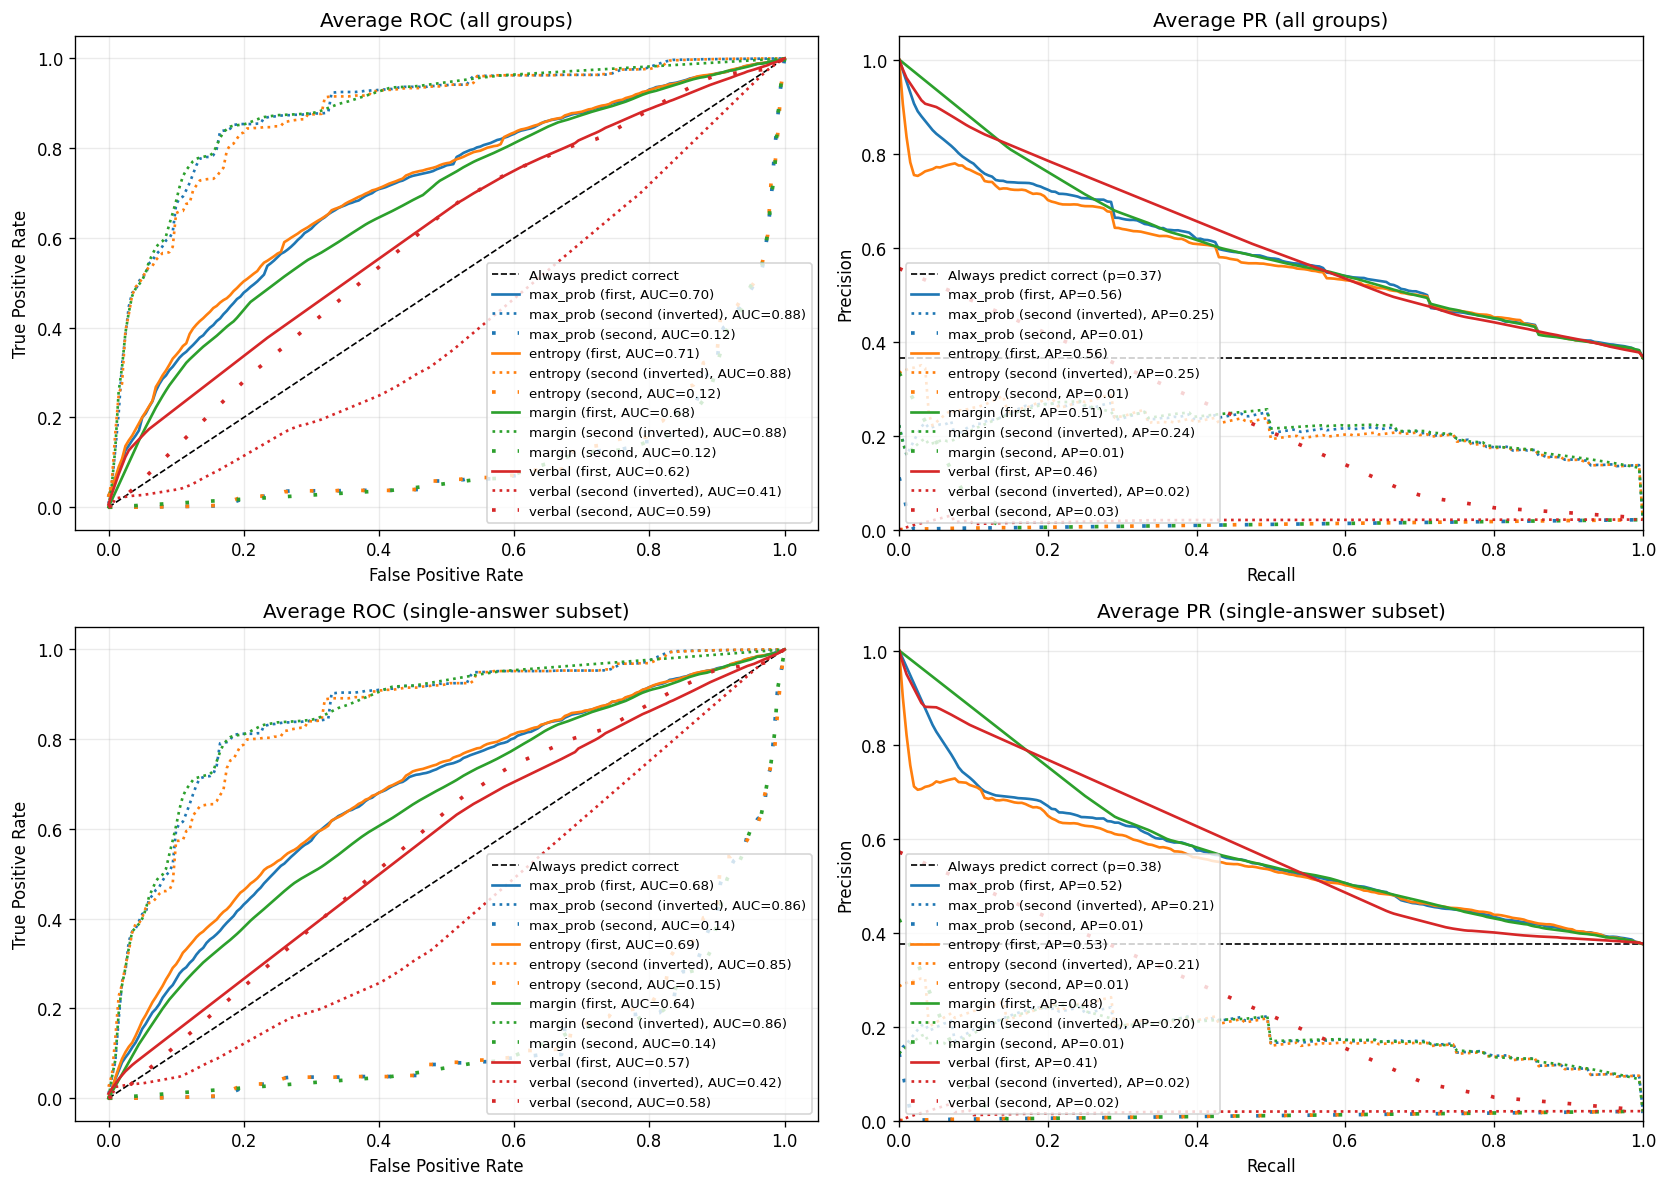

In [9]:
def plot_average_panels(frame_all: pd.DataFrame, frame_single: pd.DataFrame) -> None:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    ax_roc_all, ax_pr_all = axes[0, 0], axes[0, 1]
    ax_roc_single, ax_pr_single = axes[1, 0], axes[1, 1]

    dotted_inv = ":"
    dotted_plain_thick = (0, (1, 6))  # bigger gaps between dots
    lw_first = 1.6
    lw_second_inv = 1.6
    lw_second_plain = 2.2

    def _plot_roc(ax, frame, title):
        curves = average_roc_curves(frame)
        # Baseline: always predict "correct" (visual baseline).
        ax.plot([0, 1], [0, 1], "k--", lw=1.0, label="Always predict correct")
        for metric in METRICS:
            color = METRIC_COLORS[metric]
            # 4 lines: first/plain + second/inv + second/plain
            for (try_name, variant, linestyle, lw, label_try) in [
                ("first", "plain", "-", lw_first, "first"),
                ("second", "inv", dotted_inv, lw_second_inv, "second (inverted)"),
                ("second", "plain", dotted_plain_thick, lw_second_plain, "second"),
            ]:
                key = (try_name, metric, variant)
                if key not in curves:
                    continue
                x, y, a_ = curves[key]
                ax.plot(x, y, linestyle=linestyle, color=color, lw=lw, label=f"{metric} ({label_try}, AUC={a_:.2f})")
        ax.set_title(title)
        ax.set_xlabel("False Positive Rate")
        ax.set_ylabel("True Positive Rate")
        ax.grid(True, alpha=0.25)
        ax.legend(fontsize=8, loc="lower right")

    def _plot_pr(ax, frame, title):
        curves = average_pr_curves(frame)
        baseline = average_pr_baseline(frame)
        # Baseline: always predict "correct" (precision = prevalence).
        ax.plot([0, 1], [baseline, baseline], "k--", lw=1.0, label=f"Always predict correct (p={baseline:.2f})")
        for metric in METRICS:
            color = METRIC_COLORS[metric]
            for (try_name, variant, linestyle, lw, label_try) in [
                ("first", "plain", "-", lw_first, "first"),
                ("second", "inv", dotted_inv, lw_second_inv, "second (inverted)"),
                ("second", "plain", dotted_plain_thick, lw_second_plain, "second"),
            ]:
                key = (try_name, metric, variant)
                if key not in curves:
                    continue
                x, y, ap = curves[key]
                ax.plot(x, y, linestyle=linestyle, color=color, lw=lw, label=f"{metric} ({label_try}, AP={ap:.2f})")
        ax.set_title(title)
        ax.set_xlabel("Recall")
        ax.set_ylabel("Precision")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1.05)
        ax.grid(True, alpha=0.25)
        ax.legend(fontsize=8, loc="lower left")

    _plot_roc(ax_roc_all, frame_all, "Average ROC (all groups)")
    _plot_pr(ax_pr_all, frame_all, "Average PR (all groups)")
    _plot_roc(ax_roc_single, frame_single, "Average ROC (single-answer subset)")
    _plot_pr(ax_pr_single, frame_single, "Average PR (single-answer subset)")

    plt.tight_layout()
    plt.show()


mask_single = (~df["dataset"].str.contains("maqa", case=False, na=False)) | (df["dataset"].str.contains("single", case=False, na=False))
df_single = df[mask_single].copy()
print("Rows (all):", len(df), "Rows (single subset):", len(df_single))

plot_average_panels(df, df_single)

## Last step's modified graphs.
The AUROC subplots are put onto separate graps than the PR curves. The legends are also placed outside of the graph, under the graph, so that the lines and texts would be in columns of 3.

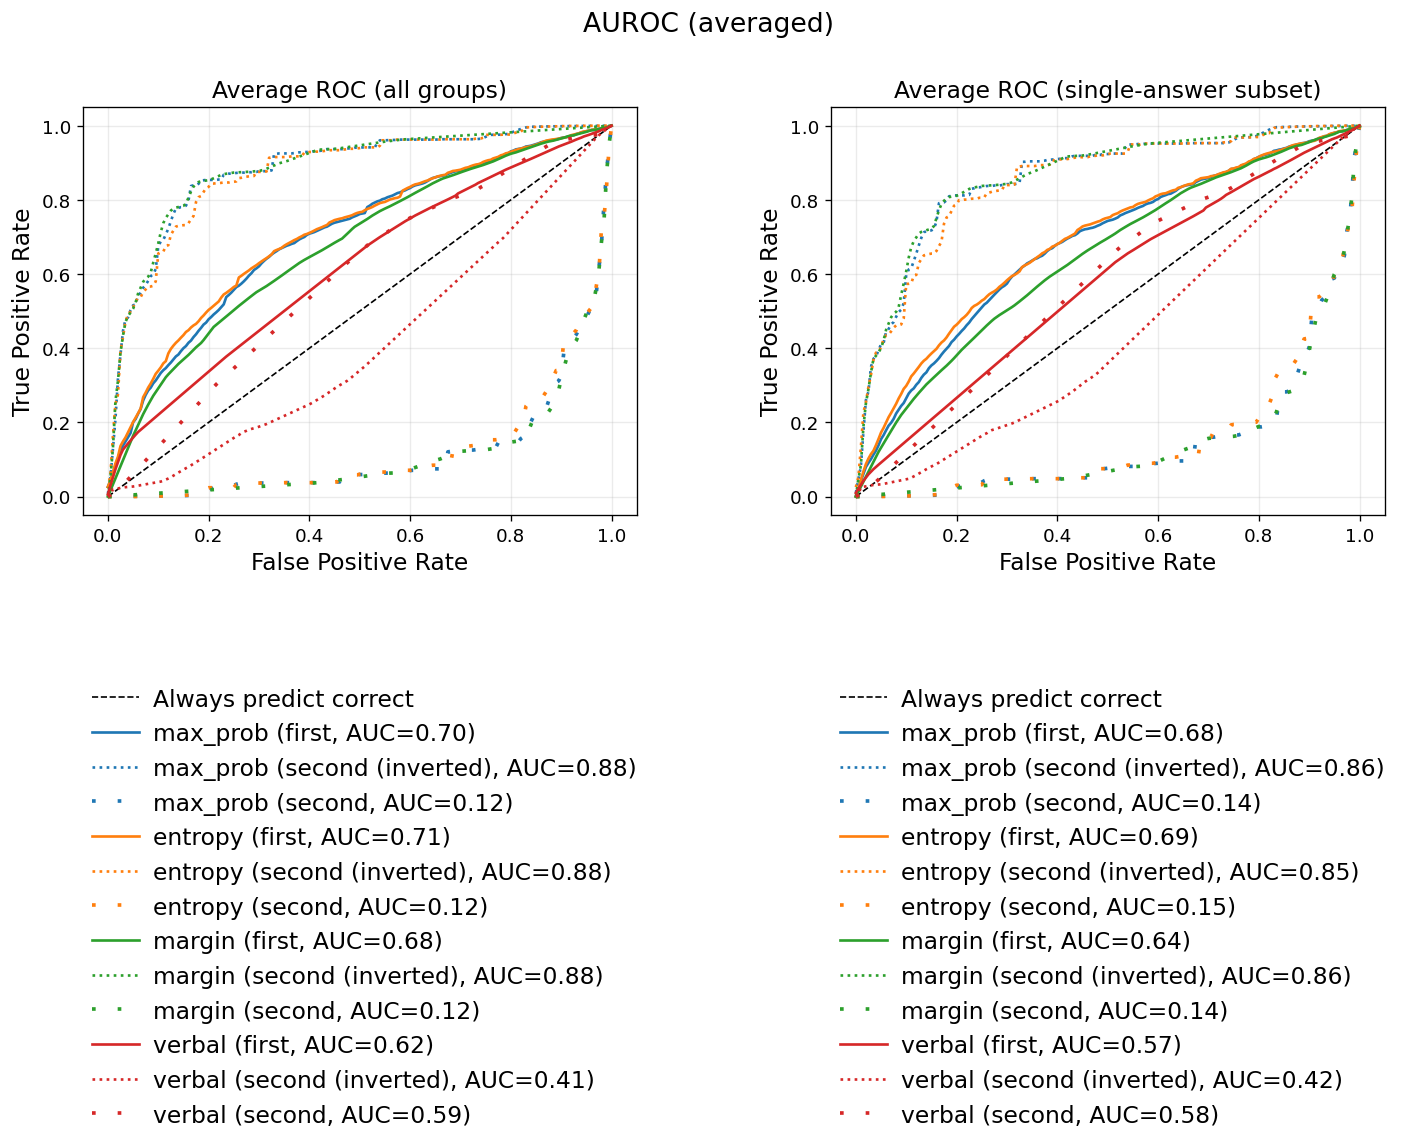

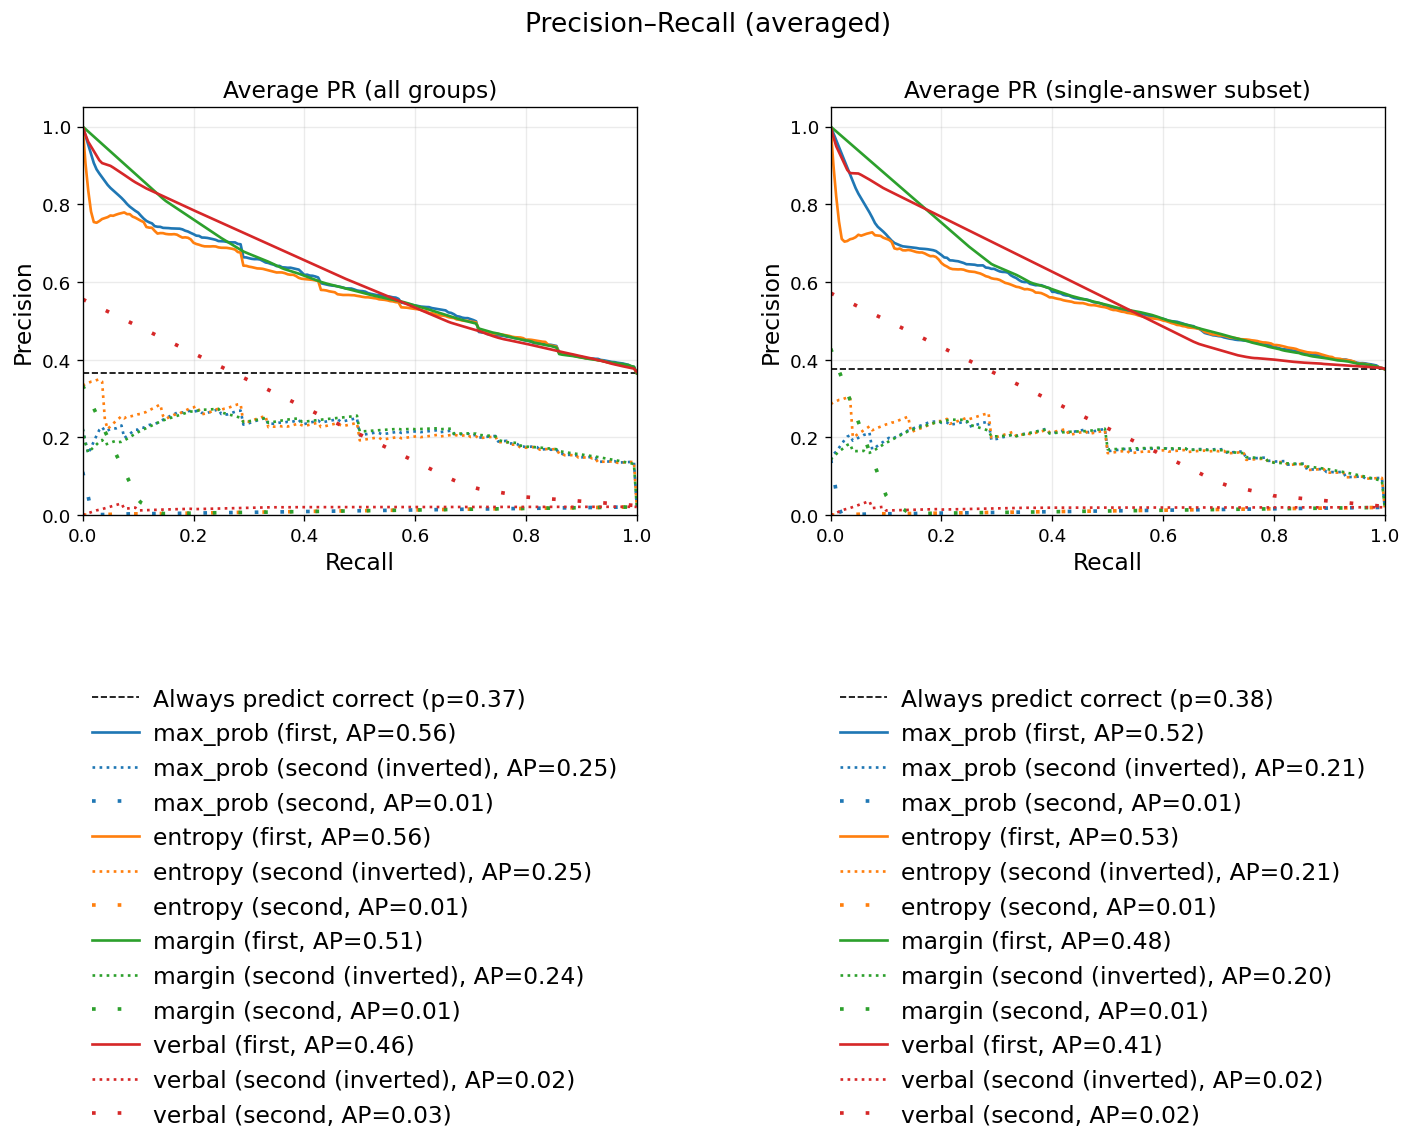

In [10]:
# Last step's modified graphs: split AUROC and PR into separate figures,
# and place legends below each subplot (separated), so they don't overlap plots.

def plot_average_panels_split(fig_title_suffix: str, frame_all: pd.DataFrame, frame_single: pd.DataFrame) -> None:
    dotted_inv = ":"
    dotted_plain_thick = (0, (1, 6))  # bigger gaps between dots
    lw_first = 1.6
    lw_second_inv = 1.6
    lw_second_plain = 2.2
    baseline_ls = "k--"
    baseline_lw = 1.0
    
    # Font sizes
    suptitle_fontsize = 16
    title_fontsize = 14
    label_fontsize = 14
    tick_fontsize = 11
    legend_fontsize = 14
    
    legend_ncol = 1  # single column (prevents collisions with long labels)
    legend_y = -0.40  # push legends further down (more room for larger fonts)
    bottom_pad = 0.56  # extra space for legends under axes
    top_pad = 0.90
    wspace = 0.35  # more horizontal space between subplots (and their legends)

    def _roc_ax(ax, frame, title):
        curves = average_roc_curves(frame)
        ax.plot([0, 1], [0, 1], baseline_ls, lw=baseline_lw, label="Always predict correct")
        for metric in METRICS:
            color = METRIC_COLORS[metric]
            for (try_name, variant, linestyle, lw, label_try) in [
                ("first", "plain", "-", lw_first, "first"),
                ("second", "inv", dotted_inv, lw_second_inv, "second (inverted)"),
                ("second", "plain", dotted_plain_thick, lw_second_plain, "second"),
            ]:
                key = (try_name, metric, variant)
                if key not in curves:
                    continue
                x, y, a_ = curves[key]
                ax.plot(x, y, linestyle=linestyle, color=color, lw=lw, label=f"{metric} ({label_try}, AUC={a_:.2f})")
        ax.set_title(title, fontsize=title_fontsize)
        ax.set_xlabel("False Positive Rate", fontsize=label_fontsize)
        ax.set_ylabel("True Positive Rate", fontsize=label_fontsize)
        ax.tick_params(axis="both", which="major", labelsize=tick_fontsize)
        ax.grid(True, alpha=0.25)

    def _pr_ax(ax, frame, title):
        curves = average_pr_curves(frame)
        baseline = average_pr_baseline(frame)
        ax.plot([0, 1], [baseline, baseline], baseline_ls, lw=baseline_lw, label=f"Always predict correct (p={baseline:.2f})")
        for metric in METRICS:
            color = METRIC_COLORS[metric]
            for (try_name, variant, linestyle, lw, label_try) in [
                ("first", "plain", "-", lw_first, "first"),
                ("second", "inv", dotted_inv, lw_second_inv, "second (inverted)"),
                ("second", "plain", dotted_plain_thick, lw_second_plain, "second"),
            ]:
                key = (try_name, metric, variant)
                if key not in curves:
                    continue
                x, y, ap = curves[key]
                ax.plot(x, y, linestyle=linestyle, color=color, lw=lw, label=f"{metric} ({label_try}, AP={ap:.2f})")
        ax.set_title(title, fontsize=title_fontsize)
        ax.set_xlabel("Recall", fontsize=label_fontsize)
        ax.set_ylabel("Precision", fontsize=label_fontsize)
        ax.tick_params(axis="both", which="major", labelsize=tick_fontsize)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1.05)
        ax.grid(True, alpha=0.25)

    def _legend_below_axis(ax):
        handles, labels = ax.get_legend_handles_labels()
        # Single-column legend per subplot, placed under its own axes.
        ax.legend(
            handles,
            labels,
            loc="upper left",
            bbox_to_anchor=(0.0, legend_y),
            bbox_transform=ax.transAxes,
            ncol=legend_ncol,
            fontsize=legend_fontsize,
            frameon=False,
            borderaxespad=0.0,
            handletextpad=0.6,
            labelspacing=0.5,
        )

    # --- ROC figure (2 subplots) ---
    fig_roc, axes_roc = plt.subplots(1, 2, figsize=(14, 10))
    _roc_ax(axes_roc[0], frame_all, "Average ROC (all groups)")
    _roc_ax(axes_roc[1], frame_single, "Average ROC (single-answer subset)")
    _legend_below_axis(axes_roc[0])
    _legend_below_axis(axes_roc[1])
    fig_roc.suptitle(f"AUROC (averaged) {fig_title_suffix}", fontsize=suptitle_fontsize)
    fig_roc.subplots_adjust(bottom=bottom_pad, top=top_pad, wspace=wspace)
    plt.show()

    # --- PR figure (2 subplots) ---
    fig_pr, axes_pr = plt.subplots(1, 2, figsize=(14, 10))
    _pr_ax(axes_pr[0], frame_all, "Average PR (all groups)")
    _pr_ax(axes_pr[1], frame_single, "Average PR (single-answer subset)")
    _legend_below_axis(axes_pr[0])
    _legend_below_axis(axes_pr[1])
    fig_pr.suptitle(f"Precision–Recall (averaged) {fig_title_suffix}", fontsize=suptitle_fontsize)
    fig_pr.subplots_adjust(bottom=bottom_pad, top=top_pad, wspace=wspace)
    plt.show()


mask_single = (~df["dataset"].str.contains("maqa", case=False, na=False)) | (df["dataset"].str.contains("single", case=False, na=False))
df_single = df[mask_single].copy()
plot_average_panels_split("", df, df_single)

## 4) Two-try combined evaluation
In this section we treat a question as **correct within two tries** if `first_try_correct == 1` **or** `second_try_correct == 1`.
We plot:
- ROC + Precision–Recall curves for this *combined* outcome (per group and averaged; all vs. single-answer subset).
- Percent answered correctly on the **first try** vs on the **second try** (where “second try correct” means *first was wrong and second was correct*), per group and averaged (all vs. single-answer subset).

In [11]:
def _combined_correct(frame: pd.DataFrame) -> np.ndarray:
    if "first_try_correct" not in frame.columns or "second_try_correct" not in frame.columns:
        raise KeyError("Need first_try_correct and second_try_correct for combined evaluation")
    first = frame["first_try_correct"].to_numpy(dtype=int)
    second = frame["second_try_correct"].to_numpy(dtype=int)
    return ((first == 1) | (second == 1)).astype(int)


def _second_try_gain(frame: pd.DataFrame) -> np.ndarray:
    """1 if wrong on first try but correct on second try."""
    first = frame["first_try_correct"].to_numpy(dtype=int)
    second = frame["second_try_correct"].to_numpy(dtype=int)
    return ((first == 0) & (second == 1)).astype(int)


def _combined_score(frame: pd.DataFrame, metric: str) -> np.ndarray:
    """Combine first+second try scores into a single score per row (best of two)."""
    c1 = _score_col("first", metric)
    c2 = _score_col("second", metric)
    if c1 not in frame.columns:
        raise KeyError(f"Missing score column: {c1}")
    s1 = _coerce_numeric(frame[c1])
    if c2 in frame.columns:
        s2 = _coerce_numeric(frame[c2])
        return np.nanmax(np.vstack([s1, s2]), axis=0)
    return s1


def compute_roc_with_inversion_decision(y_true: np.ndarray, scores: np.ndarray) -> tuple[np.ndarray, np.ndarray, float, bool] | None:
    """Return (fpr, tpr, auc, inverted) using the same inversion rule as earlier: invert if AUROC < 0.5."""
    roc_res = compute_roc(y_true, scores)
    if roc_res is None:
        return None
    fpr, tpr, roc_auc = roc_res
    inverted = False
    if roc_auc < 0.5:
        inv_scores = _invert_scores(scores)
        roc_res2 = compute_roc(y_true, inv_scores)
        if roc_res2 is not None:
            fpr, tpr, roc_auc = roc_res2
            inverted = True
    return fpr, tpr, roc_auc, inverted


def compute_pr_with_optional_inversion(y_true: np.ndarray, scores: np.ndarray, invert: bool) -> tuple[np.ndarray, np.ndarray, float] | None:
    """Compute PR, optionally inverting scores first."""
    use_scores = _invert_scores(scores) if invert else scores
    return compute_pr(y_true, use_scores)

### 4.1) ROC curves for combined (≤2 tries) correctness
Each subplot: random classifier + 4 metrics (combined score = best of first/second).
If AUROC < 0.5, the curve is inverted and marked in the legend.

Number of subplots: 11


/tmp/ipykernel_5484/2228106794.py:25: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(np.vstack([s1, s2]), axis=0)
/tmp/ipykernel_5484/2228106794.py:25: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(np.vstack([s1, s2]), axis=0)
/tmp/ipykernel_5484/2228106794.py:25: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(np.vstack([s1, s2]), axis=0)
/tmp/ipykernel_5484/2228106794.py:25: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(np.vstack([s1, s2]), axis=0)


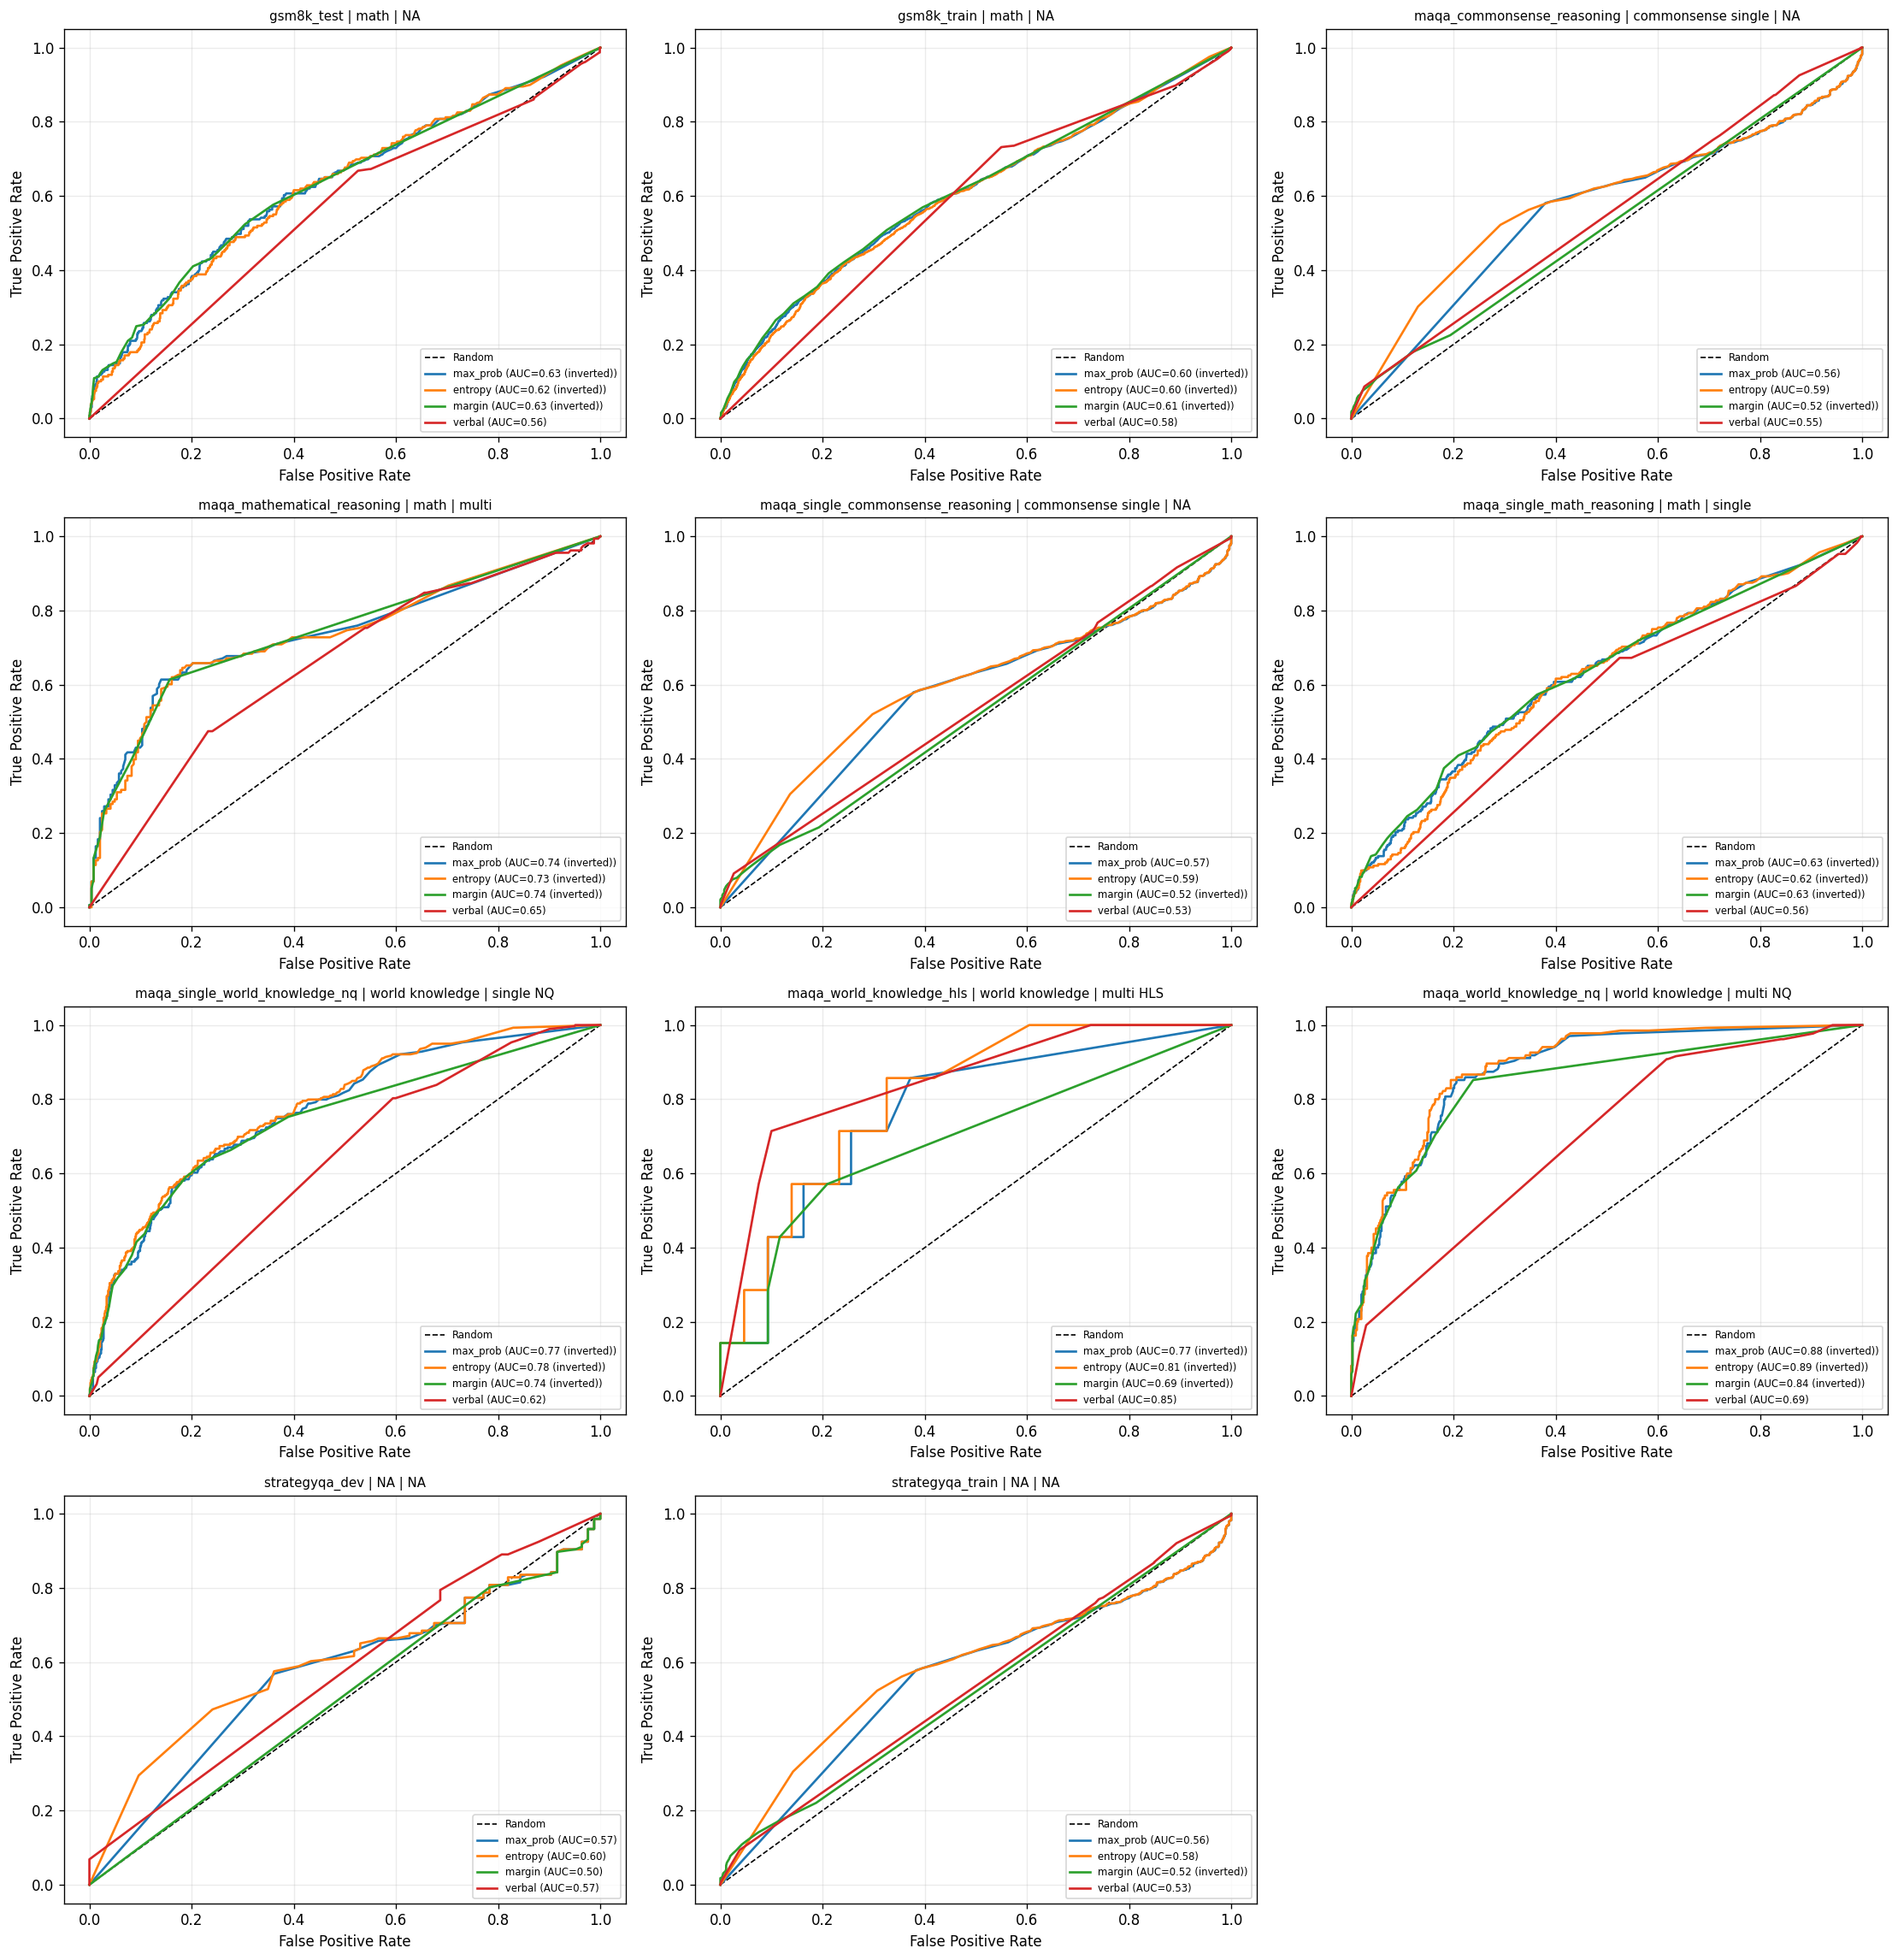

In [12]:
groups = list(iter_groups(df))
print("Number of subplots:", len(groups))

n = len(groups)
if n == 0:
    raise ValueError("No groups found to plot")

ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6.2 * ncols, 4.8 * nrows), squeeze=False)
axes_flat = axes.flatten()

for ax in axes_flat[n:]:
    ax.axis("off")

for i, ((dataset, categorie, subcategorie), g) in enumerate(groups):
    ax = axes_flat[i]
    title = f"{dataset} | {categorie} | {subcategorie}"
    ax.set_title(title, fontsize=9)
    ax.plot([0, 1], [0, 1], "k--", lw=1.0, label="Random")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.grid(True, alpha=0.25)

    y_true = _combined_correct(g)
    for metric in METRICS:
        color = METRIC_COLORS.get(metric, None)
        try:
            scores = _combined_score(g, metric)
        except KeyError:
            continue
        roc_res = compute_roc_with_inversion_decision(y_true, scores)
        if roc_res is None:
            continue
        fpr, tpr, roc_auc, inverted = roc_res
        suffix = " (inverted)" if inverted else ""
        ax.plot(fpr, tpr, color=color, lw=1.6, label=f"{metric} (AUC={roc_auc:.2f}{suffix})")

    ax.legend(fontsize=7, loc="lower right")

plt.tight_layout()
plt.show()

### 4.2) Precision–Recall curves for combined (≤2 tries) correctness
Each subplot: baseline prevalence + 4 metrics (combined score = best of first/second).
Uses the same inversion decision as ROC (invert PR scores if AUROC < 0.5).

/tmp/ipykernel_5484/2228106794.py:25: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(np.vstack([s1, s2]), axis=0)
/tmp/ipykernel_5484/2228106794.py:25: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(np.vstack([s1, s2]), axis=0)
/tmp/ipykernel_5484/2228106794.py:25: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(np.vstack([s1, s2]), axis=0)
/tmp/ipykernel_5484/2228106794.py:25: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(np.vstack([s1, s2]), axis=0)


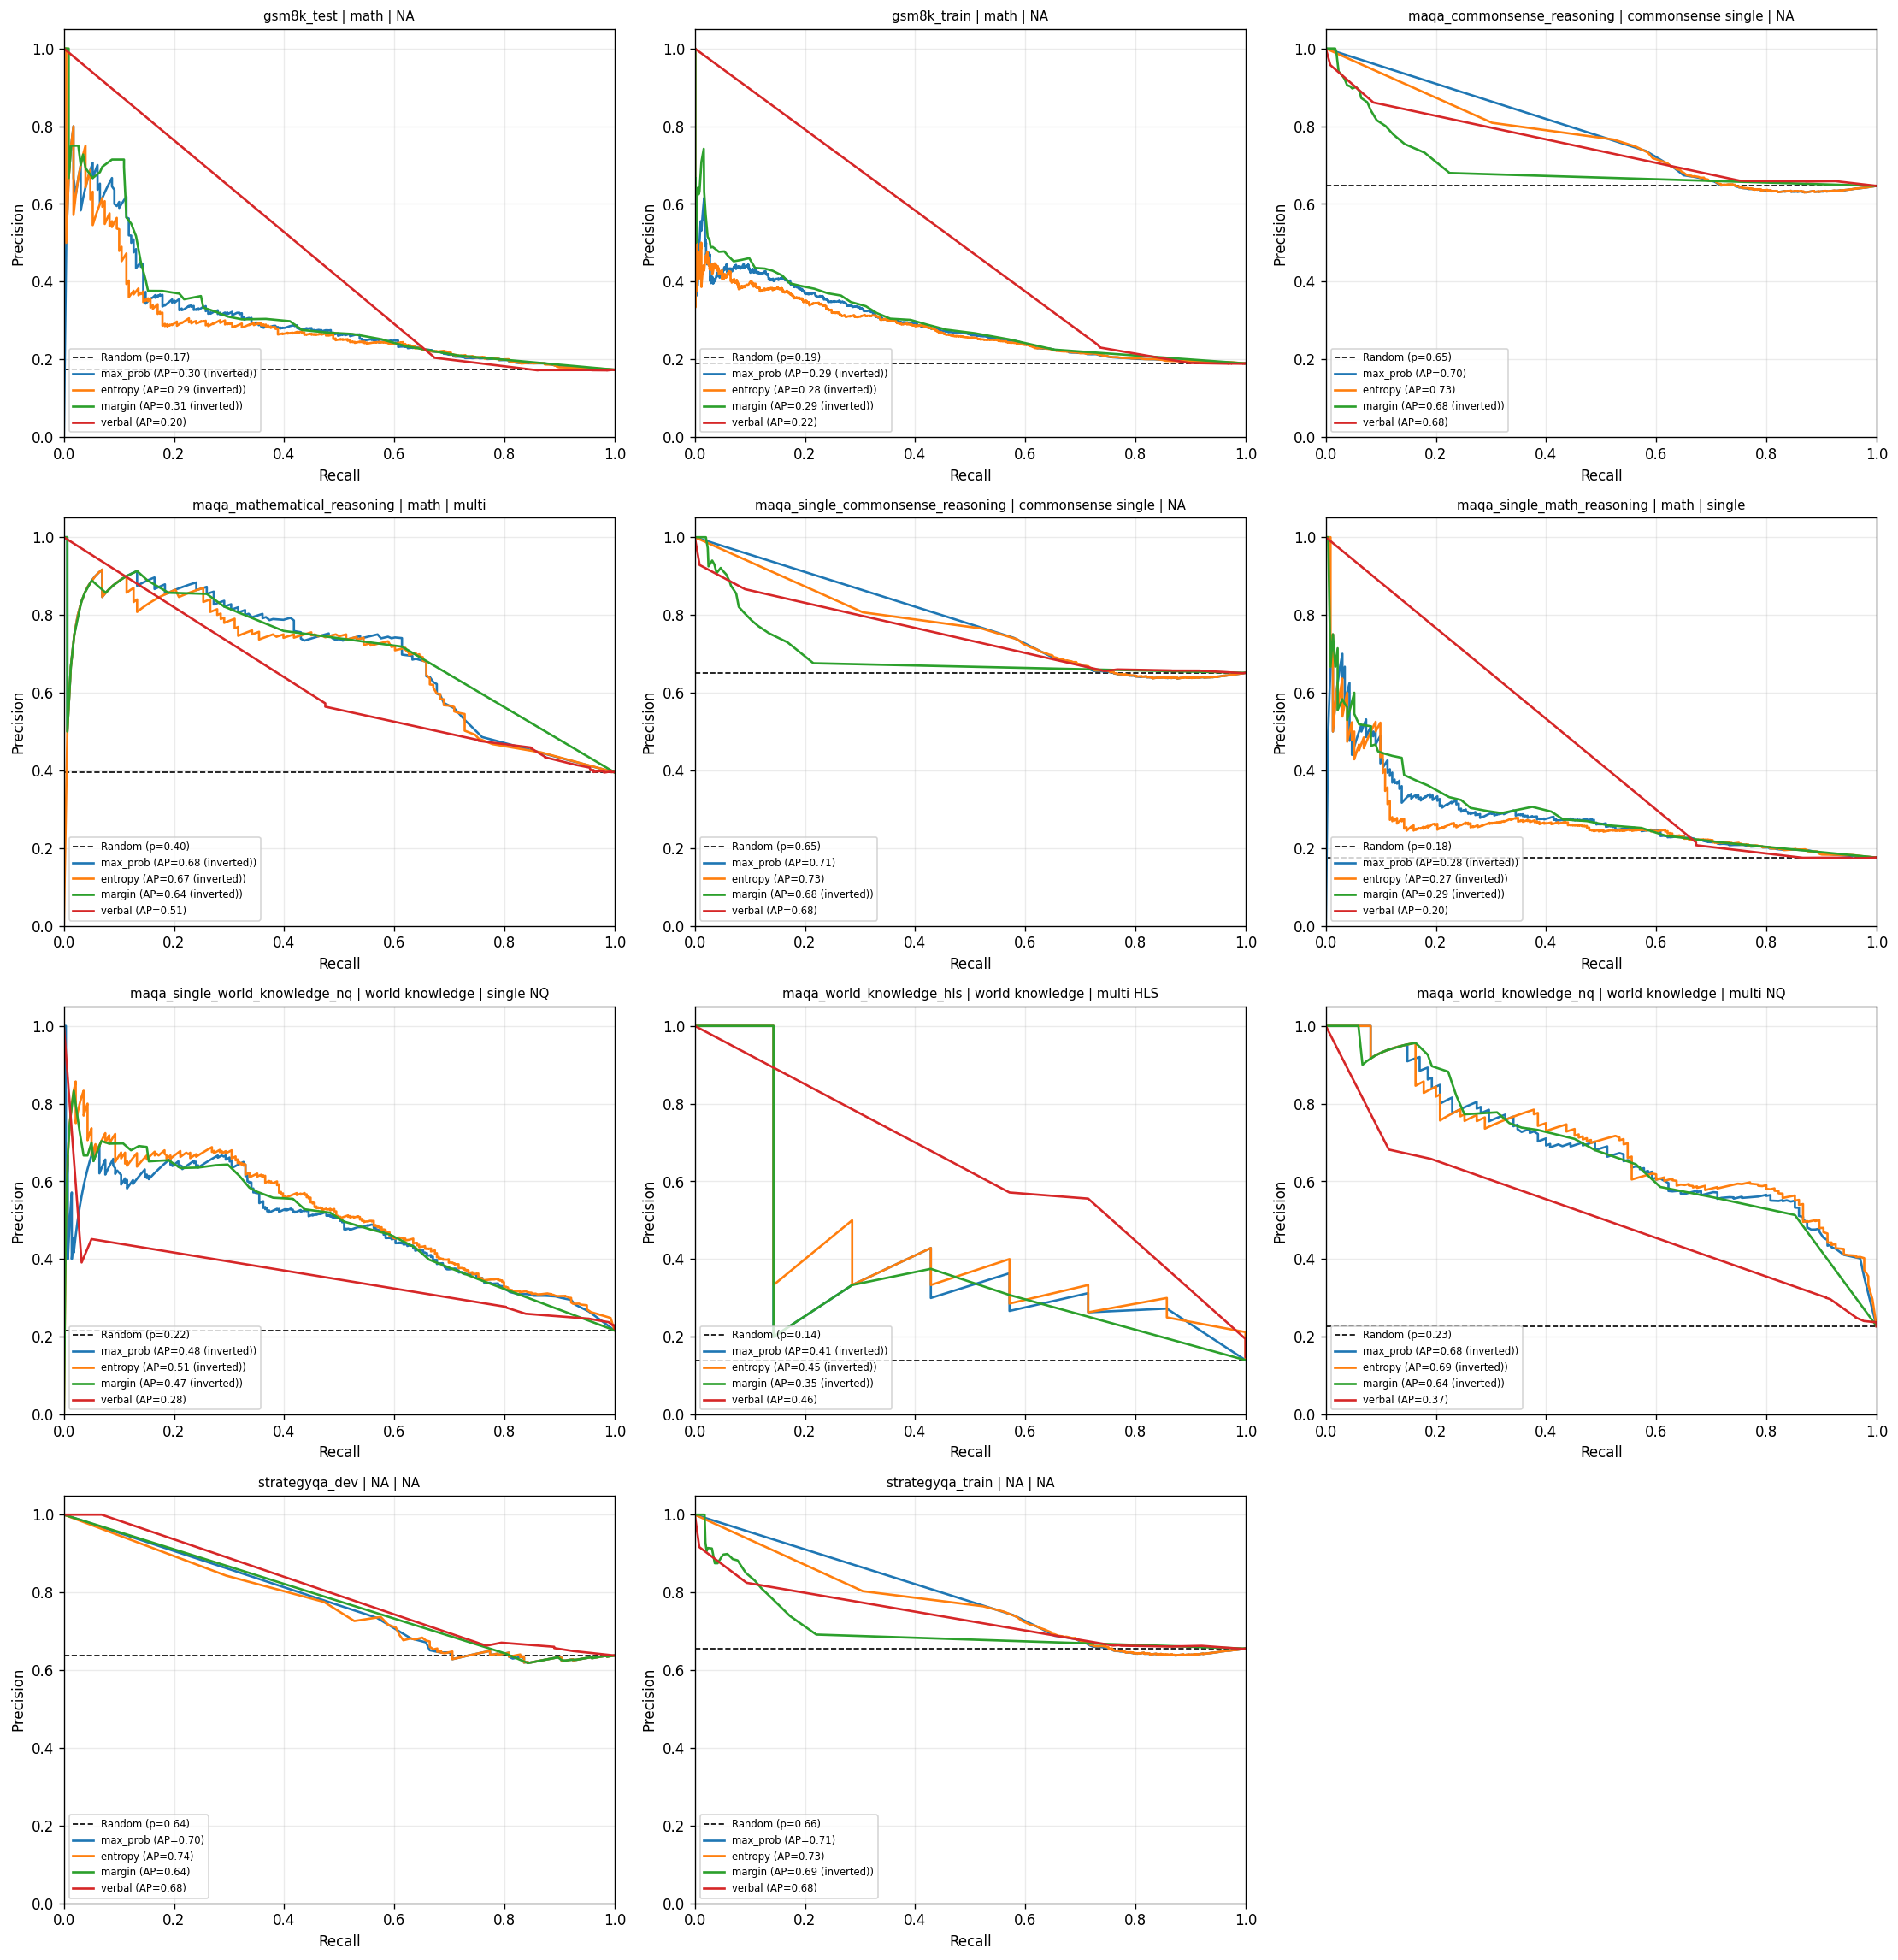

In [13]:
groups = list(iter_groups(df))
n = len(groups)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6.2 * ncols, 4.8 * nrows), squeeze=False)
axes_flat = axes.flatten()

for ax in axes_flat[n:]:
    ax.axis("off")

for i, ((dataset, categorie, subcategorie), g) in enumerate(groups):
    ax = axes_flat[i]
    title = f"{dataset} | {categorie} | {subcategorie}"
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.grid(True, alpha=0.25)

    y_true = _combined_correct(g)
    base_rate = float(np.mean(y_true)) if y_true.size else 0.0
    ax.plot([0, 1], [base_rate, base_rate], "k--", lw=1.0, label=f"Random (p={base_rate:.2f})")

    for metric in METRICS:
        color = METRIC_COLORS.get(metric, None)
        try:
            scores = _combined_score(g, metric)
        except KeyError:
            continue
        roc_res = compute_roc_with_inversion_decision(y_true, scores)
        if roc_res is None:
            continue
        _fpr, _tpr, _roc_auc, inverted = roc_res
        pr_res = compute_pr_with_optional_inversion(y_true, scores, invert=inverted)
        if pr_res is None:
            continue
        recall, precision, ap = pr_res
        suffix = " (inverted)" if inverted else ""
        ax.plot(recall, precision, color=color, lw=1.6, label=f"{metric} (AP={ap:.2f}{suffix})")

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=7, loc="lower left")

plt.tight_layout()
plt.show()

### 4.3) Averaged combined curves (4 panels)
Panels: ROC/PR averaged across groups for (1) all data and (2) single-answer subset (excluding MAQA multi-answer datasets: `maqa` and not `single`).

Rows (all): 25455 Rows (single subset): 15979


/tmp/ipykernel_5484/2228106794.py:25: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(np.vstack([s1, s2]), axis=0)
/tmp/ipykernel_5484/2228106794.py:25: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(np.vstack([s1, s2]), axis=0)
/tmp/ipykernel_5484/2228106794.py:25: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(np.vstack([s1, s2]), axis=0)
/tmp/ipykernel_5484/2228106794.py:25: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(np.vstack([s1, s2]), axis=0)
/tmp/ipykernel_5484/2228106794.py:25: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(np.vstack([s1, s2]), axis=0)
/tmp/ipykernel_5484/2228106794.py:25: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(np.vstack([s1, s2]), axis=0)
/tmp/ipykernel_5484/2228106794.py:25: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(np.vstack([s1, s2]), axis=0)
/tmp/ipykernel_5484/2228106794.py:25: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(np.vs

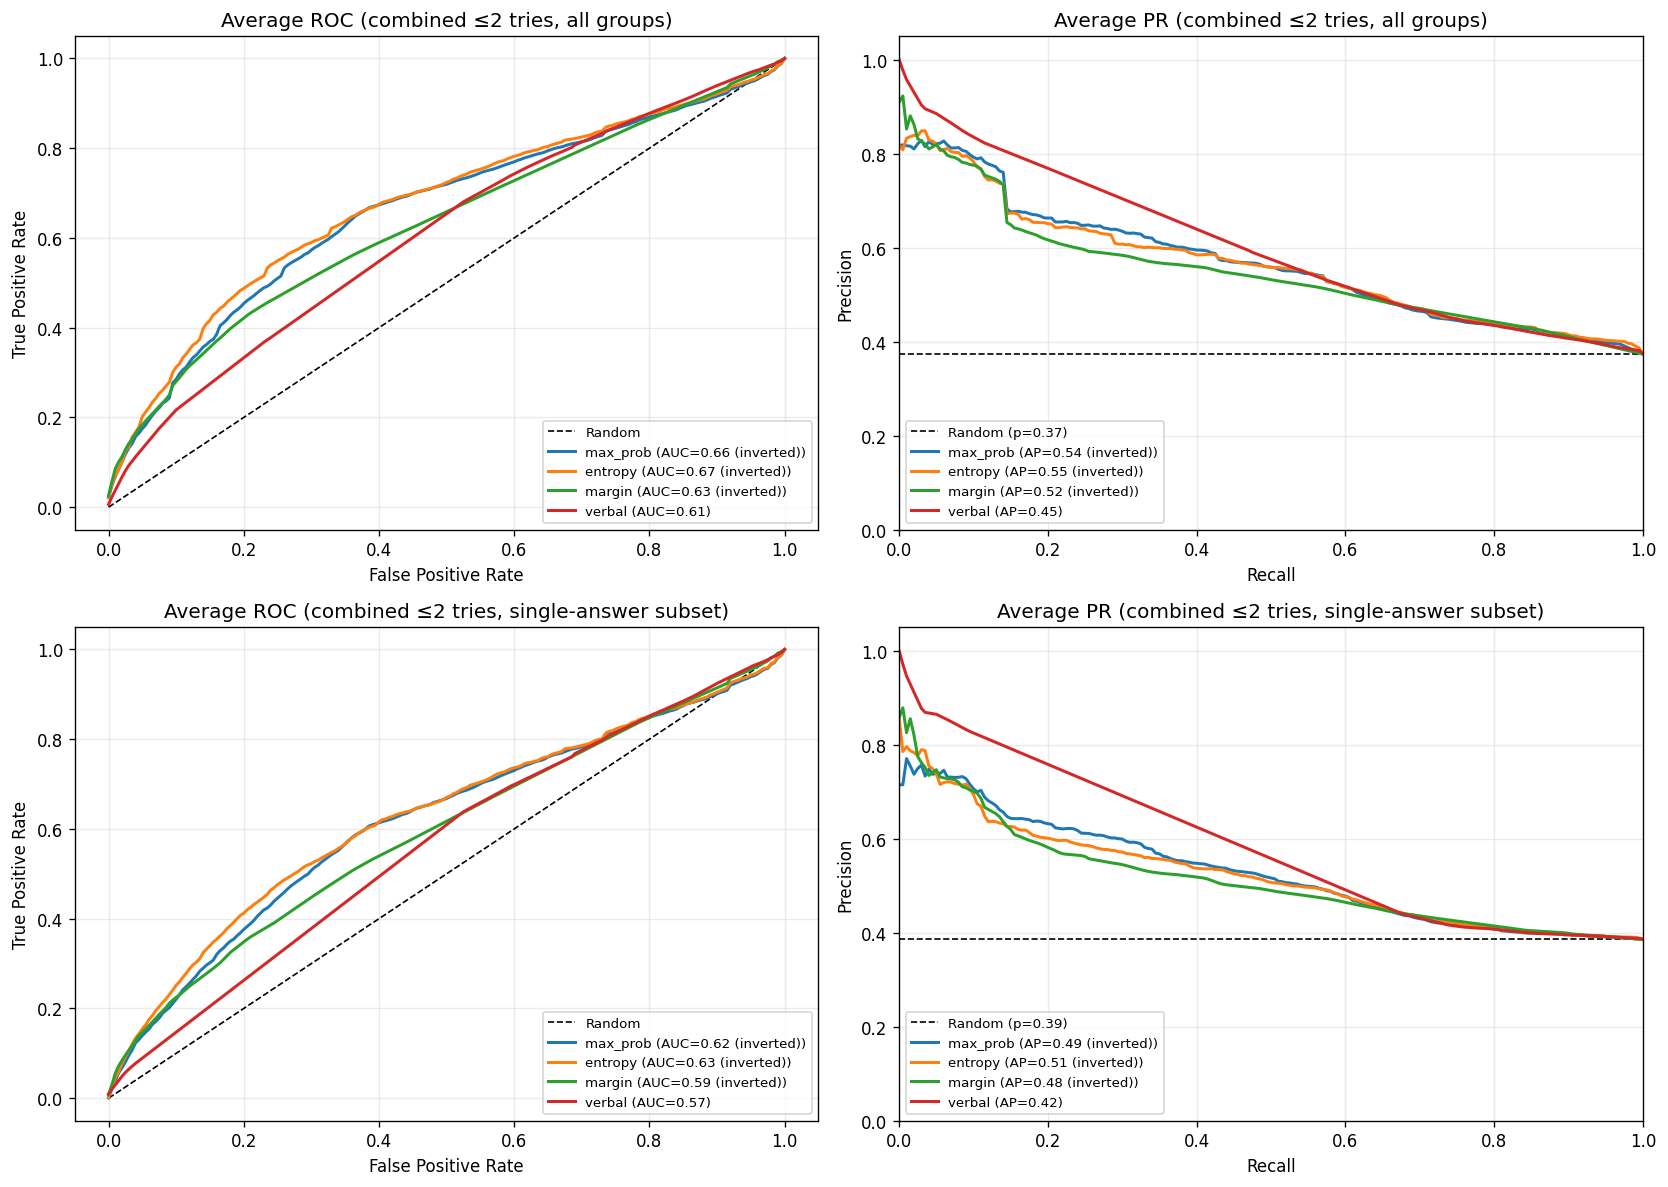

In [14]:
def average_roc_curves_combined(frame: pd.DataFrame) -> dict[str, tuple[np.ndarray, np.ndarray, float, bool]]:
    """Averaged ROC curves for combined outcome, keyed by metric.
    Returns (fpr_grid, mean_tpr, mean_auc, inverted_any).
    """
    fpr_grid = np.linspace(0.0, 1.0, 201)
    acc: dict[str, list[np.ndarray]] = {}
    aucs: dict[str, list[float]] = {}
    inverted_any: dict[str, bool] = {}
    for (_key, g) in iter_groups(frame):
        y_true = _combined_correct(g)
        for metric in METRICS:
            try:
                scores = _combined_score(g, metric)
            except KeyError:
                continue
            roc_res = compute_roc_with_inversion_decision(y_true, scores)
            if roc_res is None:
                continue
            fpr, tpr, roc_auc, inverted = roc_res
            if fpr[0] > 0:
                fpr = np.concatenate([[0.0], fpr])
                tpr = np.concatenate([[0.0], tpr])
            if fpr[-1] < 1:
                fpr = np.concatenate([fpr, [1.0]])
                tpr = np.concatenate([tpr, [1.0]])
            tpr_i = np.interp(fpr_grid, fpr, tpr)
            acc.setdefault(metric, []).append(tpr_i)
            aucs.setdefault(metric, []).append(float(roc_auc))
            inverted_any[metric] = inverted_any.get(metric, False) or inverted
    out: dict[str, tuple[np.ndarray, np.ndarray, float, bool]] = {}
    for metric, tprs in acc.items():
        mean_tpr = np.mean(np.vstack(tprs), axis=0)
        mean_auc = float(np.mean(aucs.get(metric, [np.nan])))
        out[metric] = (fpr_grid, mean_tpr, mean_auc, bool(inverted_any.get(metric, False)))
    return out


def average_pr_curves_combined(frame: pd.DataFrame) -> dict[str, tuple[np.ndarray, np.ndarray, float, bool]]:
    """Averaged PR curves for combined outcome, keyed by metric.
    Returns (recall_grid, mean_precision, mean_ap, inverted_any).
    """
    recall_grid = np.linspace(0.0, 1.0, 201)
    acc: dict[str, list[np.ndarray]] = {}
    aps: dict[str, list[float]] = {}
    inverted_any: dict[str, bool] = {}
    for (_key, g) in iter_groups(frame):
        y_true = _combined_correct(g)
        for metric in METRICS:
            try:
                scores = _combined_score(g, metric)
            except KeyError:
                continue
            roc_res = compute_roc_with_inversion_decision(y_true, scores)
            if roc_res is None:
                continue
            _fpr, _tpr, _roc_auc, inverted = roc_res
            pr_res = compute_pr_with_optional_inversion(y_true, scores, invert=inverted)
            if pr_res is None:
                continue
            recall, precision, ap = pr_res
            recall = recall[::-1]
            precision = precision[::-1]
            if recall[0] > 0:
                recall = np.concatenate([[0.0], recall])
                precision = np.concatenate([[precision[0]], precision])
            if recall[-1] < 1:
                recall = np.concatenate([recall, [1.0]])
                precision = np.concatenate([precision, [precision[-1]]])
            prec_i = np.interp(recall_grid, recall, precision)
            acc.setdefault(metric, []).append(prec_i)
            aps.setdefault(metric, []).append(float(ap))
            inverted_any[metric] = inverted_any.get(metric, False) or inverted
    out: dict[str, tuple[np.ndarray, np.ndarray, float, bool]] = {}
    for metric, precs in acc.items():
        mean_prec = np.mean(np.vstack(precs), axis=0)
        mean_ap = float(np.mean(aps.get(metric, [np.nan])))
        out[metric] = (recall_grid, mean_prec, mean_ap, bool(inverted_any.get(metric, False)))
    return out


def average_pr_baseline_combined(frame: pd.DataFrame) -> float:
    rates = []
    for (_key, g) in iter_groups(frame):
        y_true = _combined_correct(g)
        if y_true.size:
            rates.append(float(np.mean(y_true)))
    return float(np.mean(rates)) if rates else 0.0


def plot_average_panels_combined(frame_all: pd.DataFrame, frame_single: pd.DataFrame) -> None:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    ax_roc_all, ax_pr_all = axes[0, 0], axes[0, 1]
    ax_roc_single, ax_pr_single = axes[1, 0], axes[1, 1]

    def _plot_roc(ax, frame, title):
        curves = average_roc_curves_combined(frame)
        ax.plot([0, 1], [0, 1], "k--", lw=1.0, label="Random")
        for metric in METRICS:
            if metric not in curves:
                continue
            color = METRIC_COLORS[metric]
            x, y, auc_mean, inverted_any = curves[metric]
            suffix = " (inverted)" if inverted_any else ""
            ax.plot(x, y, color=color, lw=1.8, label=f"{metric} (AUC={auc_mean:.2f}{suffix})")
        ax.set_title(title)
        ax.set_xlabel("False Positive Rate")
        ax.set_ylabel("True Positive Rate")
        ax.grid(True, alpha=0.25)
        ax.legend(fontsize=8, loc="lower right")

    def _plot_pr(ax, frame, title):
        curves = average_pr_curves_combined(frame)
        baseline = average_pr_baseline_combined(frame)
        ax.plot([0, 1], [baseline, baseline], "k--", lw=1.0, label=f"Random (p={baseline:.2f})")
        for metric in METRICS:
            if metric not in curves:
                continue
            color = METRIC_COLORS[metric]
            x, y, ap_mean, inverted_any = curves[metric]
            suffix = " (inverted)" if inverted_any else ""
            ax.plot(x, y, color=color, lw=1.8, label=f"{metric} (AP={ap_mean:.2f}{suffix})")
        ax.set_title(title)
        ax.set_xlabel("Recall")
        ax.set_ylabel("Precision")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1.05)
        ax.grid(True, alpha=0.25)
        ax.legend(fontsize=8, loc="lower left")

    _plot_roc(ax_roc_all, frame_all, "Average ROC (combined ≤2 tries, all groups)")
    _plot_pr(ax_pr_all, frame_all, "Average PR (combined ≤2 tries, all groups)")
    _plot_roc(ax_roc_single, frame_single, "Average ROC (combined ≤2 tries, single-answer subset)")
    _plot_pr(ax_pr_single, frame_single, "Average PR (combined ≤2 tries, single-answer subset)")

    plt.tight_layout()
    plt.show()


mask_single = (~df["dataset"].str.contains("maqa", case=False, na=False)) | (df["dataset"].str.contains("single", case=False, na=False))
df_single = df[mask_single].copy()
print("Rows (all):", len(df), "Rows (single subset):", len(df_single))

plot_average_panels_combined(df, df_single)

### 4.4) % correct on first vs second try
Per group and averaged (all vs. single-answer subset).
Second-try % counts only cases where the first try was wrong but the second try was correct.

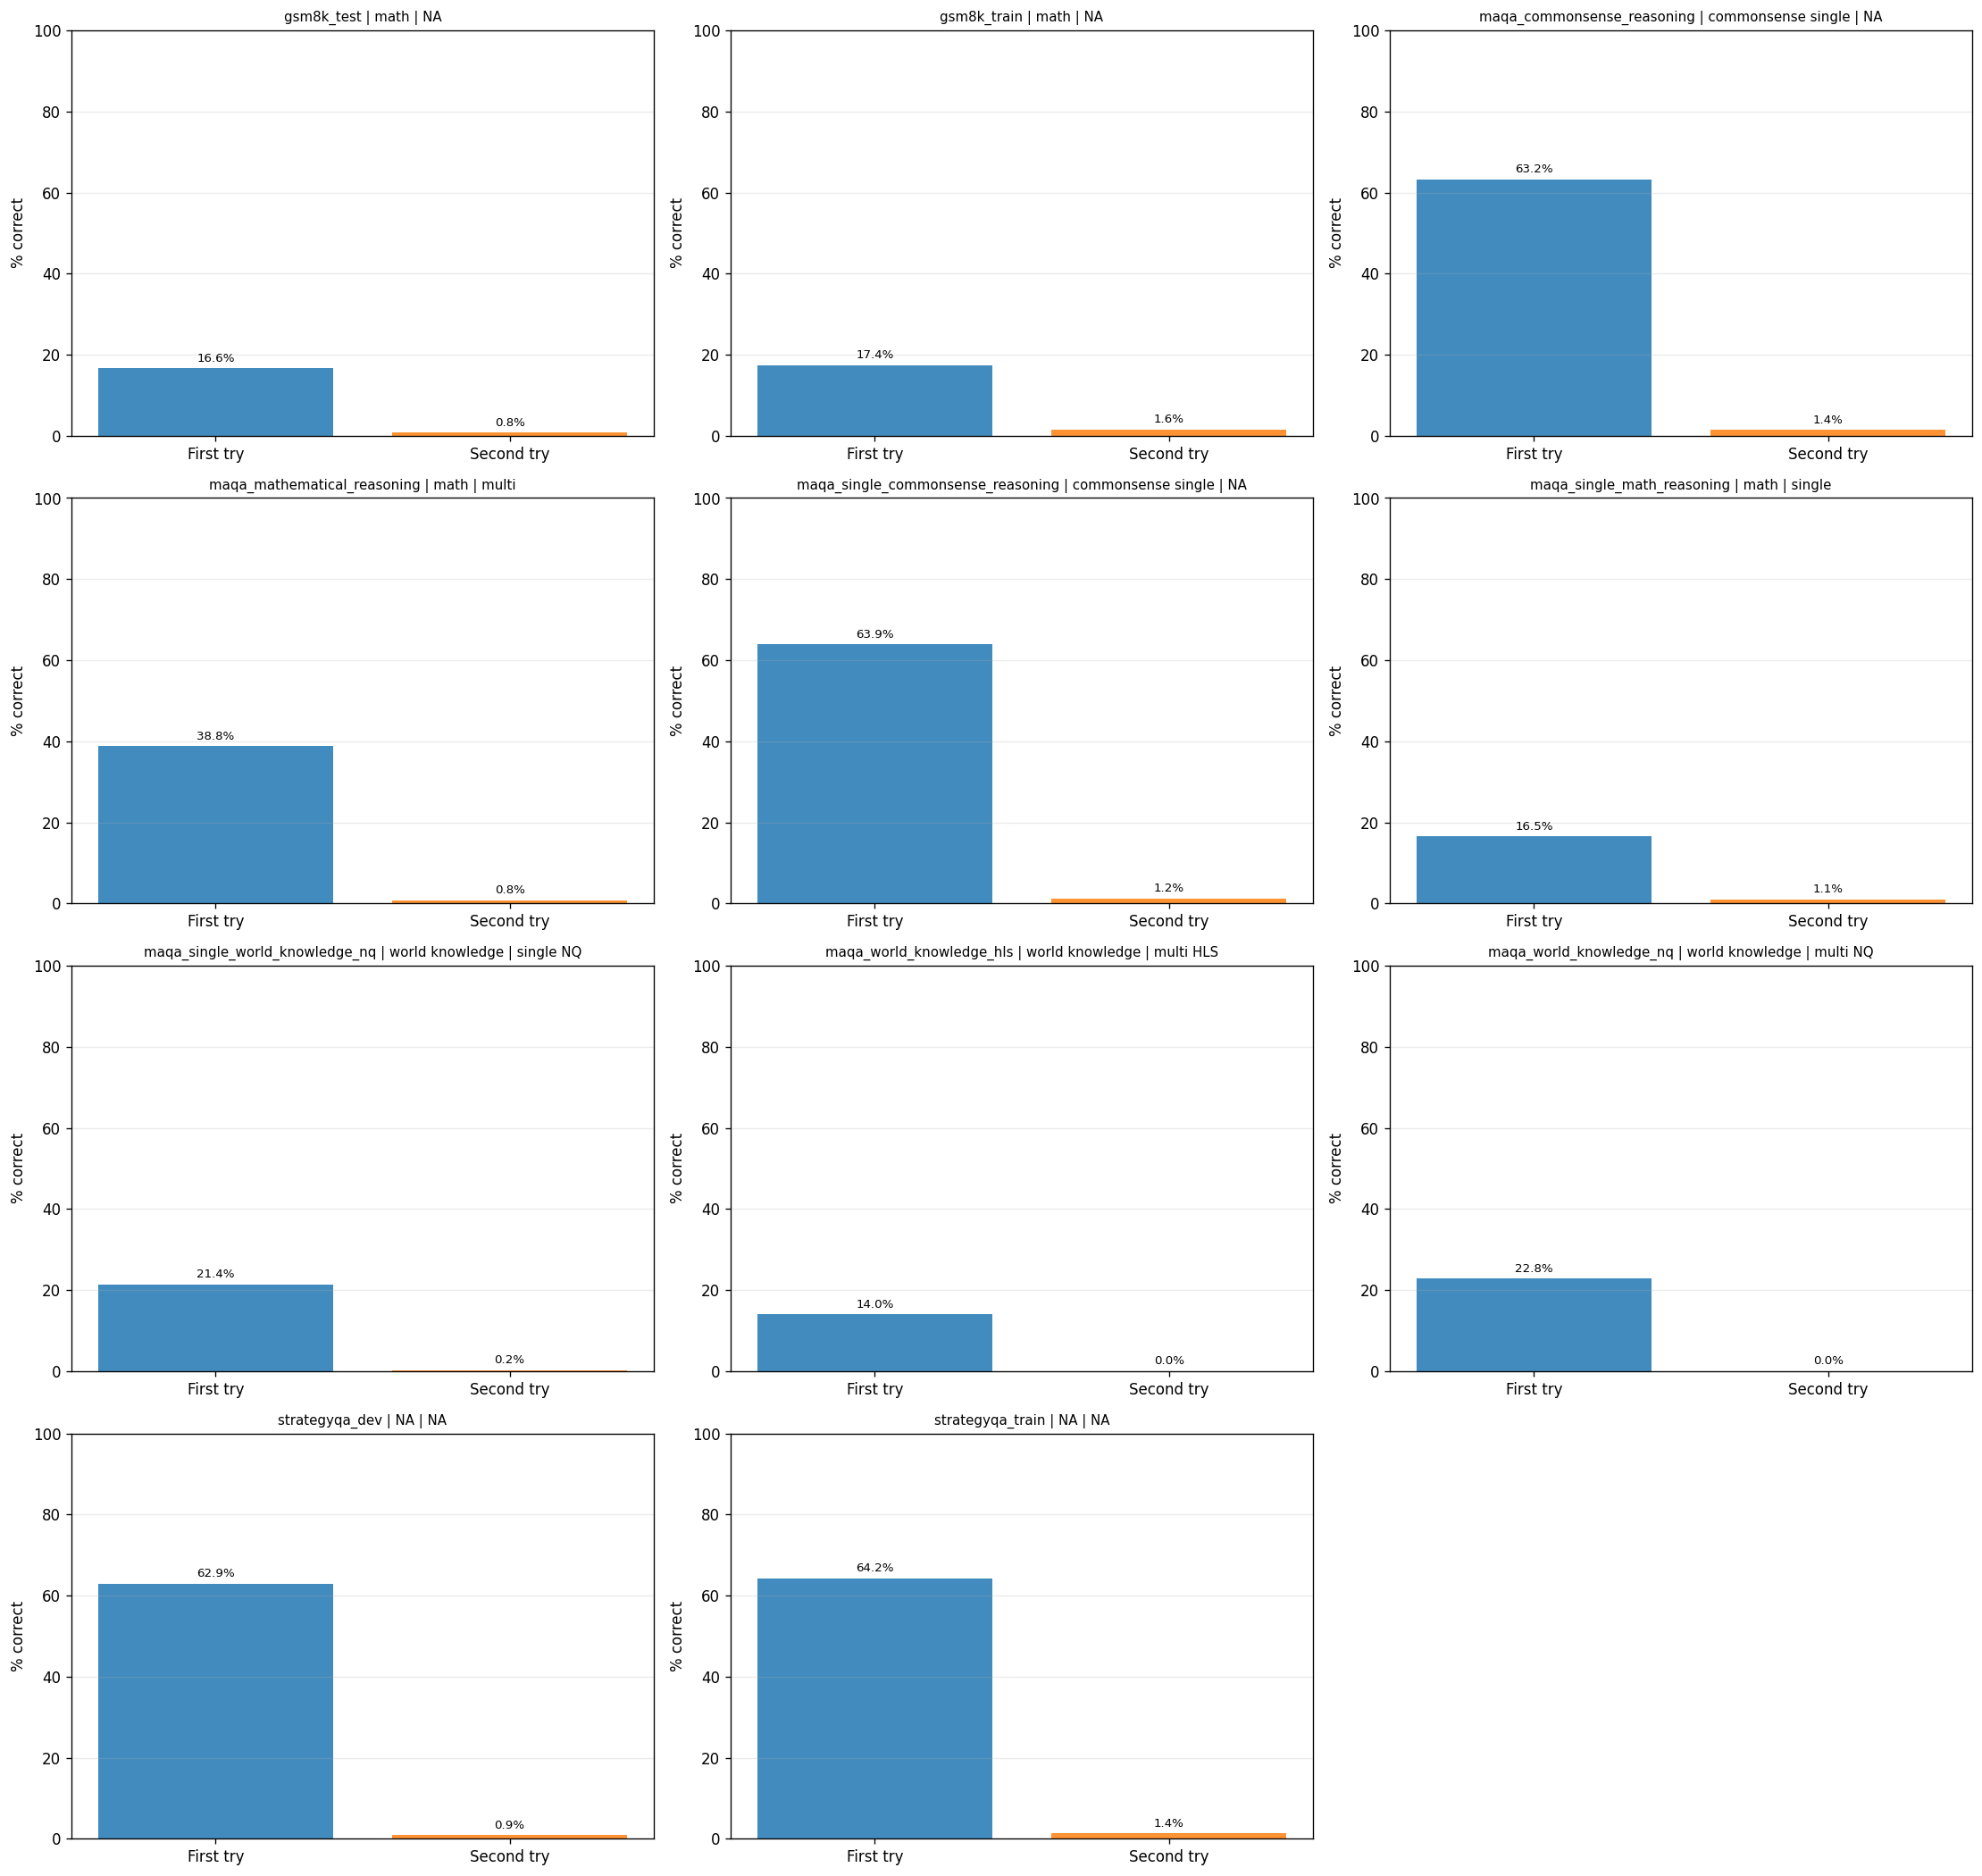

In [15]:
groups = list(iter_groups(df))
n = len(groups)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6.2 * ncols, 4.4 * nrows), squeeze=False)
axes_flat = axes.flatten()

for ax in axes_flat[n:]:
    ax.axis("off")

for i, ((dataset, categorie, subcategorie), g) in enumerate(groups):
    ax = axes_flat[i]
    title = f"{dataset} | {categorie} | {subcategorie}"
    ax.set_title(title, fontsize=9)

    first = g["first_try_correct"].to_numpy(dtype=int)
    second_gain = _second_try_gain(g)
    p_first = float(np.mean(first)) if first.size else 0.0
    p_second = float(np.mean(second_gain)) if second_gain.size else 0.0

    ax.bar([0, 1], [p_first * 100.0, p_second * 100.0], color=["tab:blue", "tab:orange"], alpha=0.85)
    ax.set_xticks([0, 1], ["First try", "Second try"], rotation=0)
    ax.set_ylabel("% correct")
    ax.set_ylim(0, 100)
    ax.grid(True, axis="y", alpha=0.25)
    ax.text(0, p_first * 100.0 + 1.0, f"{p_first*100.0:.1f}%", ha="center", va="bottom", fontsize=8)
    ax.text(1, p_second * 100.0 + 1.0, f"{p_second*100.0:.1f}%", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

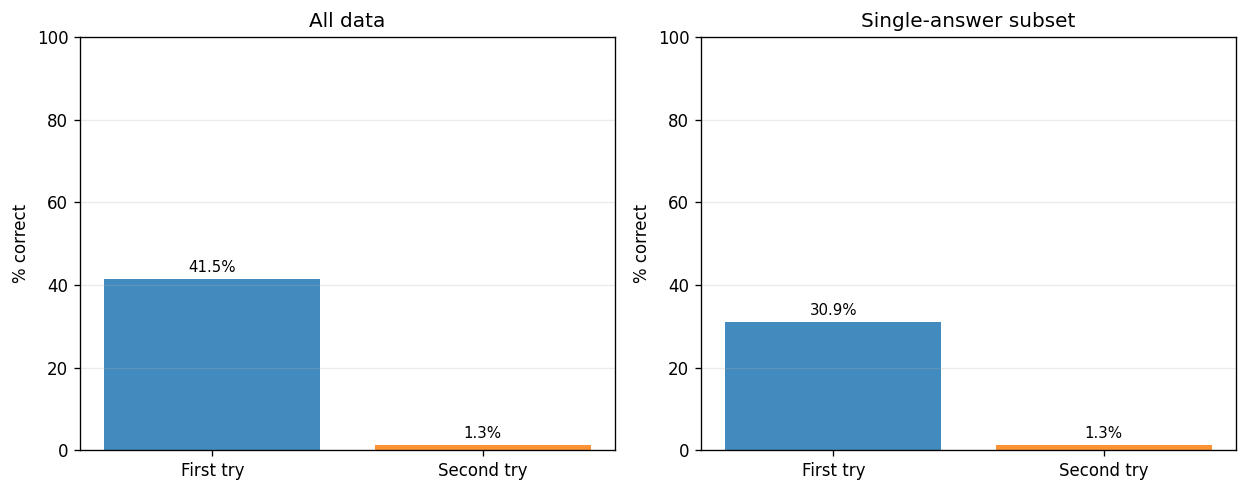

In [16]:
def plot_first_vs_second_rates(frame_all: pd.DataFrame, frame_single: pd.DataFrame) -> None:
    def _rates(frame: pd.DataFrame) -> tuple[float, float]:
        first = frame["first_try_correct"].to_numpy(dtype=int)
        second_gain = _second_try_gain(frame)
        p_first = float(np.mean(first)) if first.size else 0.0
        p_second = float(np.mean(second_gain)) if second_gain.size else 0.0
        return p_first, p_second

    p1_all, p2_all = _rates(frame_all)
    p1_s, p2_s = _rates(frame_single)

    fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
    for ax, (p1, p2, title) in zip(
        axes,
        [
            (p1_all, p2_all, "All data"),
            (p1_s, p2_s, "Single-answer subset"),
        ],
    ):
        ax.bar([0, 1], [p1 * 100.0, p2 * 100.0], color=["tab:blue", "tab:orange"], alpha=0.85)
        ax.set_xticks([0, 1], ["First try", "Second try"], rotation=0)
        ax.set_ylabel("% correct")
        ax.set_ylim(0, 100)
        ax.set_title(title)
        ax.grid(True, axis="y", alpha=0.25)
        ax.text(0, p1 * 100.0 + 1.0, f"{p1*100.0:.1f}%", ha="center", va="bottom", fontsize=9)
        ax.text(1, p2 * 100.0 + 1.0, f"{p2*100.0:.1f}%", ha="center", va="bottom", fontsize=9)

    plt.tight_layout()
    plt.show()


mask_single = (~df["dataset"].str.contains("maqa", case=False, na=False)) | (df["dataset"].str.contains("single", case=False, na=False))
df_single = df[mask_single].copy()
plot_first_vs_second_rates(df, df_single)